# PMO via the branching process

This notebook implements `docs/post_isolation_pmo_methodology.pdf` on a simulated population.
Every quantity here comes from 1000 simulated patients (the real Singapore resident age
pyramid, Ejima et al.'s NLME parameter draws, vaccination status split 50/50), starting from
the very first cell. `pdf_pmo_1d_sampled` and `pdf_pmo_2d_sampled` (eq 7.1's class-weighted
fixed point) are the only fixed points defined here. Every plot builds on them directly.
There's no median-trajectory approximation anywhere in this notebook.

**Design choices:**
- $\kappa$ (the Hill-function scale) is fixed at Ejima et al.'s own published $0.546$/day and
  never rescaled. Applying it unscaled to this simulated population's mean gives
  $\mathcal R_0\approx3.15$ already, close to the PDF's claimed $\approx3$ target. No
  correction is needed.
- Every parameter is drawn per patient, with age entering raw through $\xi$'s covariate
  rather than a fixed reference age. We didn't use a single representative trajectory. This
  is what lets every downstream quantity (transmission potential, PMO, excess burden)
  reflect real population heterogeneity instead of a 2-point approximation.

**Equation index** (PDF eq numbers; every one implemented here on per-patient arrays):

| PDF eq | What | Where |
|---|---|---|
| (8.6)-(8.7) | NLME population parameters, per-patient draws | `draw_params` |
| (8.1)-(8.5) | TCL ODE, both branches, per patient | `solve_full` |
| (2.1),(8.8) | $\beta_i(\tau)=f(V_i(\tau))$, Hill infectiousness | `beta_profile` |
| (2.2) | $B_i=\int_0^\infty\beta_i\,d\tau$, $\kappa$ fixed (not rescaled) | `B_pop` |
| (3.2)-(3.3) | $R_i^{(\text{iso})}(Q)$, per patient | `B_iso_per_patient` |
| (3.4) | $R_i^{(\text{post})}(Q)$, per patient | `B_post_per_patient` |
| (7.1) | class-weighted fixed point (class = individual simulated patient) | `pdf_pmo_1d_sampled`/`pdf_pmo_2d_sampled` |
| (6.3) | $P(\geq1\text{ transmission})$ | `prob_any_transmission` |
| (6.4)/(7.2) | post-release outbreak probability, ambient $p_{\text{out}}$ | Plot 3 |
| (5.1) + $\varphi$ free | partial isolation compliance | `pdf_pmo_1d_sampled_phi` |
| (2.3)-(2.5) + $\eta$ free | acquisition-side susceptibility | `pdf_pmo_1d_sampled_eta` |


## Setup

In [1]:
import re
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from scipy.integrate import solve_ivp

plt.style.use(["science", "notebook", "no-latex"])
mpl.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.top": False,
    "ytick.right": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.minor.visible": False,
    "ytick.minor.visible": True,
})
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

## Population simulation, step 1: NLME parameter draws

**Per-patient parameters, eq (8.6)-(8.7).** For $p\in\{\gamma,\delta,\xi,V_0\}$ (viral
replication rate, infected-cell clearance, target-cell infection rate, symptom-onset viral
load), each simulated patient's own value is drawn as
$$\ln p_i = \ln \tilde p_s + Z_{p,i}, \qquad \tilde p_s=p_0\ \text{or}\ p_0 e^{c_{p,v}},\qquad Z_{p,i}\sim\mathcal N(0,\omega_p^2)$$
This is a status-specific median $\tilde p_s$ (vaccination covariate $c_{p,v}$, zero for
$\gamma$), plus an individual lognormal random effect $Z_{p,i}$, drawn independently per
parameter per patient. $\xi$ (Ejima et al.'s own $\beta$, renamed here to avoid colliding
with $\beta_i(\tau)$, the infectiousness profile below) is the only parameter that also
carries an age covariate, $c_{\xi,\text{age}}$.

**Design choices:**
- The age covariate uses each patient's actual sampled age, not a fixed reference age. This
  is what lets age heterogeneity propagate into the population's transmission-potential
  distribution.
- Values are Ejima et al.'s Table 2 point estimates.


In [2]:
# NLME population estimates (Table 2, Ejima et al. 2025)
GAMMA_POP, OMEGA_GAMMA                          = 4.25,     3.05          # day^-1, viral-replication rate
DELTA_POP, COV_VAX_DELTA, OMEGA_DELTA           = 0.67,     0.95,  0.48   # day^-1, infected-cell death rate
XI_POP,    COV_AGE_XI,    COV_VAX_XI, OMEGA_XI  = 8.03e-7, -0.05, -1.81, 0.77   # (copies/mL)^-1 day^-1
V0_POP,    COV_VAX_V0,    OMEGA_V0              = 8.98e7,   1.26,  2.29   # copies/mL


def draw_params(n, vaccinated, age, rng=None):
    """n individuals' (gamma, delta, xi, V0), eq (8.6)-(8.7): lognormal, independent random
    effects, age entering raw (not centred) through xi only. Matches Ejima.ipynb's own
    draw_params exactly."""
    rng = rng or np.random.default_rng()
    v = 1.0 if vaccinated else 0.0
    gamma = GAMMA_POP * np.exp(rng.normal(0.0, OMEGA_GAMMA, n))
    delta = DELTA_POP * np.exp(COV_VAX_DELTA * v + rng.normal(0.0, OMEGA_DELTA, n))
    xi    = XI_POP    * np.exp(COV_AGE_XI * age + COV_VAX_XI * v + rng.normal(0.0, OMEGA_XI, n))
    V0    = V0_POP    * np.exp(COV_VAX_V0 * v + rng.normal(0.0, OMEGA_V0, n))
    return gamma, delta, xi, V0

## Population simulation, step 2: age and vaccination status

Age is drawn from the actual Singapore resident population by single year (SingStat table
M810731, `docs/Ejima supporting code/supplementary-material/Singapore-population-2023.csv`).
The weighted single-year sampling matches Ejima et al.'s own `4_Guideline.R`, including its
lack of an adult-only filter. That means this draws from the whole population, so some
simulated patients are minors, just as the R script actually behaves. Vaccination status is
50/50.

**Design choice:** age is sampled per patient from the real pyramid rather than fixed at a
single cohort-mean reference age. Age heterogeneity, via $\xi$'s covariate, then propagates
into the simulated population's transmission-potential distribution.


In [3]:
def load_sg_age_distribution(path):
    """SingStat table M810731, 'Singapore Residents' total block only, single-year ages
    0-89 plus a 90-and-over bucket at age 90."""
    ages, counts = [], []
    in_total_block = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith("Singapore Residents,"):
                in_total_block = True
                continue
            if line.startswith("Singapore Male Residents,"):
                break
            if not in_total_block:
                continue
            m = re.match(r"^(\d+)\s+Year,(\d+)$", line)
            if m:
                ages.append(int(m.group(1)))
                counts.append(int(m.group(2)))
            m90 = re.match(r"^90 Years & Over,(\d+)$", line)
            if m90:
                ages.append(90)
                counts.append(int(m90.group(1)))
    ages, counts = np.array(ages), np.array(counts, dtype=float)
    return ages, counts / counts.sum()


SG_POP_PATH = "data/Singapore-population-2023.csv"
SG_AGES, SG_PROPORTIONS = load_sg_age_distribution(SG_POP_PATH)
SG_MEAN = np.sum(SG_AGES * SG_PROPORTIONS)


def sample_population(n, seed):
    """Weighted single-year age draw from the real Singapore resident pyramid (no
    adult-only filter), vaccination status 50/50. Matches Ejima.ipynb's own sample_population."""
    rng = np.random.default_rng(seed)
    age = rng.choice(SG_AGES, size=n, replace=True, p=SG_PROPORTIONS).astype(float)
    vac = rng.integers(0, 2, n).astype(float)
    return age, vac, rng

## Population simulation, step 3: per-patient viral-load trajectories

This is a two-state reduced TCL model (PDF eq 8.2-8.4), solved separately for each patient
using their own draw of $\gamma_i,\delta_i,\xi_i,V_{0,i}$, with both branches running from
symptom onset ($t=0$):
$$\dot f = -\xi_i f V, \qquad \dot V = \gamma_i f V - \delta_i V, \qquad f(0)=1,\ V(0)=V_{0,i}$$

**Design choices:**
- The $\pm80$d window (`T_MAX_FULL`) is generous by construction. Viral load numerically
  collapses to the $10^{-12}$ floor within $5$-$10$d either side of symptom onset for most
  patients, so $\pm80$d is non-binding rather than a tuned value.
- $N=1000$ patients, `seed=2000`. This is fixed for reproducibility of every downstream
  figure in this notebook.


In [4]:
T_MAX_FULL = 80.0
T_FWD = np.arange(0.0, T_MAX_FULL + 1.0, 1.0)
T_BWD = np.arange(0.0, -T_MAX_FULL - 1.0, -1.0)
T_FULL = np.concatenate([T_BWD[::-1], T_FWD[1:]])
IDX0 = T_BWD.size - 1   # column index of t=0 (symptom onset) in the concatenated grid


def _rhs(t, y, xi, gamma, delta):
    f, V = y
    return [-xi * f * V, gamma * f * V - delta * V]


def solve_full(age, vac, rng):
    """Solves both branches per (age, vac) pair (Tmin=-80, Tmax=80, step=1). Returns an
    (n, 161) array of log10(V); column IDX0 -> t=0. Failed solves are NaN rows."""
    n = len(age)
    logV = np.full((n, T_BWD.size + T_FWD.size - 1), np.nan)
    for i in range(n):
        gamma, delta, xi, V0 = draw_params(1, bool(vac[i]), age=age[i], rng=rng)
        args = (xi[0], gamma[0], delta[0])
        sol_f = solve_ivp(_rhs, (0.0, T_MAX_FULL), [1.0, V0[0]], args=args,
                           method="LSODA", rtol=1e-8, atol=1e-10, dense_output=True)
        sol_b = solve_ivp(_rhs, (0.0, -T_MAX_FULL), [1.0, V0[0]], args=args,
                           method="LSODA", rtol=1e-8, atol=1e-10, dense_output=True)
        if sol_f.success and sol_b.success:
            Vf = sol_f.sol(T_FWD)[1]
            Vb = sol_b.sol(T_BWD)[1]
            logVf = np.log10(np.clip(Vf, 1e-12, None))
            logVb = np.log10(np.clip(Vb, 1e-12, None))
            logV[i] = np.concatenate([logVb[::-1][:-1], logVf])
    return logV


N_POP = 1000
age_pop, vac_pop, rng_pop = sample_population(N_POP, seed=2000)
logV_pop_full = solve_full(age_pop, vac_pop, rng_pop)
vac_mask = vac_pop.astype(bool)

n_ok = (~np.isnan(logV_pop_full).all(axis=1)).sum()
print(f"Population: {N_POP} simulated patients ({int((~vac_mask).sum())} unvaccinated, "
      f"{int(vac_mask.sum())} vaccinated), {n_ok}/{N_POP} solves succeeded")
print(f"Sampled age: mean={age_pop.mean():.2f}  sd={age_pop.std():.2f}  "
      f"(Singapore population mean={SG_MEAN:.2f})")
print(f"Sampled age range: {age_pop.min():.0f} to {age_pop.max():.0f}  "
      f"({int((age_pop < 18).sum())}/{N_POP} under 18, no adult-only filter, matching the R script)")

Population: 1000 simulated patients (501 unvaccinated, 499 vaccinated), 1000/1000 solves succeeded
Sampled age: mean=40.81  sd=21.87  (Singapore population mean=41.65)
Sampled age range: 0 to 90  (180/1000 under 18, no adult-only filter, matching the R script)


## Infectiousness and calibration, eq (2.1)-(2.2), (8.8)

$$\beta_i(\tau) = \kappa\frac{V_i(\tau)^\alpha}{V_i(\tau)^\alpha+\lambda^\alpha}, \qquad \kappa=0.546\ \text{day}^{-1},\ \alpha=0.8,\ \lambda=10^7$$
applied per patient. $B_i=\int_0^\infty\beta_i\,d\tau$ (eq 2.2) is each patient's total
transmission potential.

**Design choices:**
- $\kappa$ is fixed, not rescaled. The PDF's $\S8$ presents $\kappa=0.546$/day as a given
  constant rather than something to re-derive per sub-population, so $R_0$ is reported here,
  not imposed.
- Using $\kappa=0.546$ directly, the $\theta$-weighted population mean of $B_i$ gives
  $\mathcal R_0\approx3.15$, already close to the PDF's claimed target of $\approx3$ (eq 8.8).
  No correction is needed. This lands near target because calibration is anchored to the
  population mean. For a right-skewed lognormal population (here $\omega_\gamma=3.05$), the
  mean sits above the median, by Jensen's inequality. Ejima et al.'s published $\kappa$ was
  evidently calibrated against their own fitted population mean, so anchoring to this
  population's mean needs almost no correction.


In [5]:
KAPPA, ALPHA_HILL, LAMBDA_HILL = 0.546, 0.8, 1e7


def beta_profile(logV):
    V = 10.0 ** logV
    return KAPPA * V**ALPHA_HILL / (V**ALPHA_HILL + LAMBDA_HILL**ALPHA_HILL)


beta_pop = beta_profile(logV_pop_full)          # (n_pop, 161), kappa fixed -- no rescale
B_pop = np.nansum(beta_pop, axis=1)             # per-patient B_i, eq (2.2)

THETA_VAX_COHORT = 0.5   # population vaccinated proportion (matches the simulated ~50/50 split)
R0_ACTUAL = (THETA_VAX_COHORT * np.nanmean(B_pop[vac_mask])
             + (1 - THETA_VAX_COHORT) * np.nanmean(B_pop[~vac_mask]))
print(f"Population-mean R0, kappa fixed at {KAPPA}/day (not rescaled): {R0_ACTUAL:.4f}")
print("(Close to the PDF's own claimed ~3 target already -- no correction applied or needed.)")

Population-mean R0, kappa fixed at 0.546/day (not rescaled): 3.1505
(Close to the PDF's own claimed ~3 target already -- no correction applied or needed.)


## Per-patient $R_i^{(\text{iso})}(Q)$ and $R_i^{(\text{post})}(Q)$, eq (3.2)-(3.4)

`B_iso` uses a "fixed backward/presymptomatic AUC plus forward tail from $Q$" construction.
`B_post` (eq 3.4) uses the post-release-only forward tail. Both are vectorized over 1000
patients:
$$R_i^{(\text{iso})}(Q) = \underbrace{\textstyle\sum_{t<0}\beta_i(t)}_{\text{fixed}} + \sum_{t\geq Q}\beta_i(t), \qquad R_i^{(\text{post})}(Q) = \sum_{t\geq Q}\beta_i(t)$$

**Design choices:**
- $\varepsilon=0$ (perfectly leak-proof isolation) and $\tau_{\text{det}}=0$ (detection equals
  symptom onset). Both are locked throughout this notebook.
- $\eta=1$ throughout this section, so recipient susceptibility is identical regardless of
  vaccination (see the eq-(2.3)-(2.5) generalization near the end of this notebook). That
  means $R_i=\bar\eta B_i=B_i$ exactly.


In [6]:
Q_RANGE_FIX = np.arange(0, 31)


def B_iso_per_patient(beta_pop, Q_values):
    auc_backward = np.nansum(beta_pop[:, :IDX0], axis=1)          # (n_pop,)
    out = np.empty((beta_pop.shape[0], len(Q_values)))
    for j, Q in enumerate(Q_values):
        out[:, j] = auc_backward + np.nansum(beta_pop[:, IDX0 + Q:], axis=1)
    return out


def B_post_per_patient(beta_pop, Q_values):
    out = np.empty((beta_pop.shape[0], len(Q_values)))
    for j, Q in enumerate(Q_values):
        out[:, j] = np.nansum(beta_pop[:, IDX0 + Q:], axis=1)
    return out


R_iso_pop = B_iso_per_patient(beta_pop, Q_RANGE_FIX)
R_post_pop = B_post_per_patient(beta_pop, Q_RANGE_FIX)

R_v_i, R_u_i = R_iso_pop[vac_mask], R_iso_pop[~vac_mask]                 # (m_v/m_u, len(Q_RANGE_FIX))
Rpost_v_i, Rpost_u_i = R_post_pop[vac_mask], R_post_pop[~vac_mask]

print(f"Mean R_i^(iso)(Q=0): vaccinated={np.nanmean(R_v_i[:, 0]):.3f}  "
      f"unvaccinated={np.nanmean(R_u_i[:, 0]):.3f}")
print(f"Pooled theta-weighted mean R(Q=0) = "
      f"{THETA_VAX_COHORT*np.nanmean(R_v_i[:,0]) + (1-THETA_VAX_COHORT)*np.nanmean(R_u_i[:,0]):.4f} "
      f"(matches R0_ACTUAL by construction)")

Mean R_i^(iso)(Q=0): vaccinated=2.388  unvaccinated=3.913
Pooled theta-weighted mean R(Q=0) = 3.1505 (matches R0_ACTUAL by construction)


## The population-sampled fixed point, eq (7.1)

$$q = \theta\Big[\frac{1}{m_v}\sum_{i=1}^{m_v} e^{-R_{v,i}^{(\text{iso})}(Q_v)(1-q)}\Big] + (1-\theta)\Big[\frac{1}{m_u}\sum_{i=1}^{m_u} e^{-R_{u,i}^{(\text{iso})}(Q_u)(1-q)}\Big], \qquad \text{PMO}=1-q$$

`pdf_pmo_1d_sampled` handles the shared-$Q$ case and `pdf_pmo_2d_sampled` handles independent
$(Q_u,Q_v)$. `prob_any_transmission` is eq (6.3).

**Design choice:** the 2D solver runs a full 3-way Picard iteration rather than one broadcast
per axis. $q$ is a single scalar fixed point that both pools' exponentials depend on jointly,
through $(1-q)$, even though each pool's own exponential term depends only on its own $Q$.
Because $q$ mixes both pools, it can't be solved axis by axis. The whole grid has to be
iterated to convergence together.

**Sanity checks:**
- Collapsing every simulated patient onto one shared scalar $R$ should reproduce the textbook
  single-type Poisson branching-process fixed point exactly.
- The 2D fixed point's diagonal (equal $Q$ on both axes) should match the 1D version.


In [7]:
def prob_any_transmission(R):
    """P(>=1 secondary infection), eq (6.3)."""
    return 1.0 - np.exp(-np.asarray(R, dtype=float))


def pdf_pmo_1d_sampled(R_v_i, R_u_i, theta_vax, n_iter=300, tol=1e-8):
    """eq (7.1), phi=1/eps=0/eta=1, shared Q axis: each pool's own exponential averaged over
    its simulated patients before combining across pools."""
    n_Q = R_v_i.shape[1]
    q = np.zeros(n_Q)
    for _ in range(n_iter):
        g_v = np.nanmean(np.exp(-R_v_i * (1.0 - q)[None, :]), axis=0)
        g_u = np.nanmean(np.exp(-R_u_i * (1.0 - q)[None, :]), axis=0)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


def pdf_pmo_2d_sampled(R_v_i, R_u_i, theta_vax, n_iter=300, tol=1e-8):
    """eq (7.1) on the independent (Q_unvax, Q_vax) grid -- full 3-way Picard iteration."""
    n_Q = R_v_i.shape[1]
    q = np.zeros((n_Q, n_Q))   # [Qu_idx, Qv_idx]
    for _ in range(n_iter):
        one_minus_q = 1.0 - q
        g_v = np.nanmean(np.exp(-R_v_i.T[None, :, :] * one_minus_q[:, :, None]), axis=2)
        g_u = np.nanmean(np.exp(-R_u_i.T[:, None, :] * one_minus_q[:, :, None]), axis=2)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


def combined_min_days(grid, thresh, Q_grid):
    """Minimal total Qu+Qv with grid<thresh, tie-broken by lowest risk (deepest margin)."""
    feas = grid < thresh
    if not feas.any():
        return None
    total_days = Q_grid[:, None] + Q_grid[None, :]
    min_total = np.where(feas, total_days, np.inf).min()
    tied = feas & (total_days == min_total)
    idx = np.unravel_index(np.argmin(np.where(tied, grid, np.inf)), grid.shape)
    return int(Q_grid[idx[0]]), int(Q_grid[idx[1]]), grid[idx]


def worst_subgroup_min_days(metric_u, metric_v, thresh, Q_grid):
    """Each group's own minimum Q clearing thresh against its own single-type curve --
    independent 1D crossings, no joint search (contrast combined_min_days above)."""
    feas_u = metric_u < thresh
    feas_v = metric_v < thresh
    qu = int(Q_grid[feas_u].min()) if feas_u.any() else None
    qv = int(Q_grid[feas_v].min()) if feas_v.any() else None
    return qu, qv


# Sanity check 1: a population where every patient shares one scalar R must reduce to the
# textbook single-type fixed point q=exp(-R*(1-q)).
def _pmo_scalar(Rv, Ru, theta, n_iter=300, tol=1e-8):
    q = 0.0
    for _ in range(n_iter):
        nq = theta * np.exp(-Rv * (1 - q)) + (1 - theta) * np.exp(-Ru * (1 - q))
        if abs(nq - q) < tol:
            q = nq
            break
        q = nq
    return 1 - q


_Rv_deg = np.tile([3.0] * len(Q_RANGE_FIX), (10, 1))
_Ru_deg = np.tile([5.0] * len(Q_RANGE_FIX), (12, 1))
print("Scalar-population check:", np.max(np.abs(
    pdf_pmo_1d_sampled(_Rv_deg, _Ru_deg, 0.5) - _pmo_scalar(3.0, 5.0, 0.5))))

# Sanity check 2: 2D diagonal must match 1D exactly.
_diag = np.diagonal(pdf_pmo_2d_sampled(R_v_i, R_u_i, THETA_VAX_COHORT))
_oneD = pdf_pmo_1d_sampled(R_v_i, R_u_i, THETA_VAX_COHORT)
print("2D-diagonal-matches-1D check:", np.max(np.abs(_diag - _oneD)))

MARKERS_2 = ["o", "^", "s"]

Scalar-population check: 0.0


2D-diagonal-matches-1D check: 1.2771508206554927e-07


## Plot 1: transmission and outbreak probability by vaccination group

We compare three cases: unvaccinated-only ($\theta_g=0$), vaccinated-only ($\theta_g=1$), and
pooled ($\theta_g=\theta=0.5$), each isolating for the same shared $Q$. Setting $\theta_g=0$
or $1$ in `pdf_pmo_1d_sampled` reduces it to a single-pool average over just that group's
simulated patients, so no new function is needed. Two metrics recur throughout this notebook:
1a is
$P(\text{transmit})(Q)=\theta_g[1-\text{mean}_i e^{-R_{v,i}(Q)}]+(1-\theta_g)[1-\text{mean}_i e^{-R_{u,i}(Q)}]$
(eq 6.3, population-averaged), and 1b is PMO $=p_{\text{out}}$ (eq 7.1).


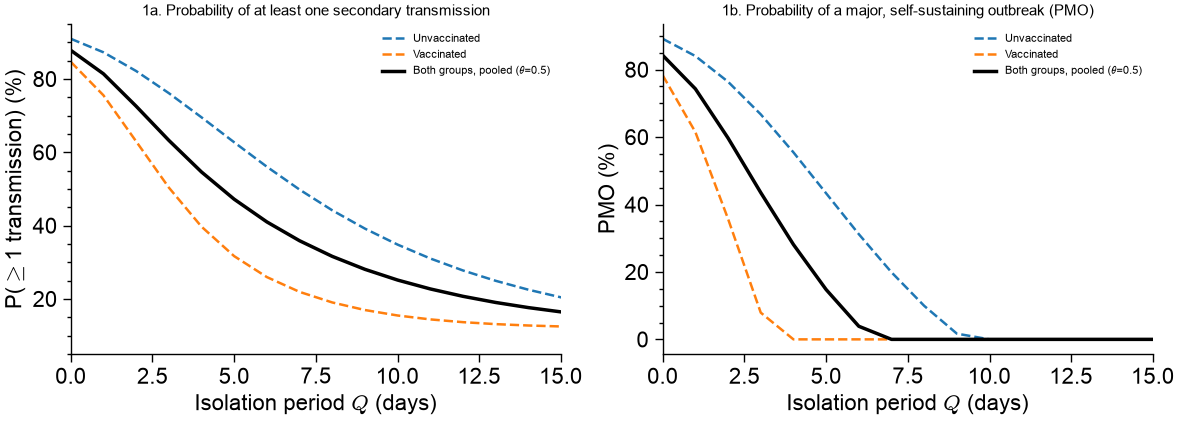

  Q   unvax PMO   vax PMO   pooled PMO
  0      89.16%    78.33%       84.25%
  2      76.41%    35.74%       59.70%


  4      55.47%     0.00%       28.13%
  6      31.20%     0.00%        3.88%
  8       9.95%     0.00%        0.00%


 10       0.00%     0.00%        0.00%


In [8]:
GROUPS_3 = [
    ("Unvaccinated", "tab:blue", 0.0),
    ("Vaccinated", "tab:orange", 1.0),
    (r"Both groups, pooled ($\theta$=0.5)", "black", THETA_VAX_COHORT),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

for ax, is_pmo, long_title, short_label, letter in [
    (axes[0], False, "Probability of at least one secondary transmission",
     r"P($\geq$1 transmission) (%)", "1a"),
    (axes[1], True, "Probability of a major, self-sustaining outbreak (PMO)",
     "PMO (%)", "1b"),
]:
    for label, color, theta_g in GROUPS_3:
        if is_pmo:
            curve = pdf_pmo_1d_sampled(R_v_i, R_u_i, theta_g)
        else:
            curve = (theta_g * np.nanmean(prob_any_transmission(R_v_i), axis=0)
                     + (1 - theta_g) * np.nanmean(prob_any_transmission(R_u_i), axis=0))
        pooled = "pooled" in label
        ax.plot(Q_RANGE_FIX, 100 * curve, color=color, lw=2.5 if pooled else 1.8,
                ls="-" if pooled else "--", label=label)
    ax.set_xlabel("Isolation period $Q$ (days)")
    ax.set_ylabel(short_label)
    ax.set_xlim(0, 15)
    ax.set_title(f"{letter}. {long_title}", fontsize=10.5)
    ax.legend(frameon=False, fontsize=8)
    ax.tick_params(top=False, right=False)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# fig.suptitle("""Plot 1: transmission and outbreak probability vs. isolation period,
# by vaccination group (population-sampled, 1000 patients)""", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"{'Q':>3}  {'unvax PMO':>10}  {'vax PMO':>8}  {'pooled PMO':>11}")
for qi in [0, 2, 4, 6, 8, 10]:
    pmo_u = pdf_pmo_1d_sampled(R_v_i, R_u_i, 0.0)[qi]
    pmo_v = pdf_pmo_1d_sampled(R_v_i, R_u_i, 1.0)[qi]
    pmo_p = pdf_pmo_1d_sampled(R_v_i, R_u_i, THETA_VAX_COHORT)[qi]
    print(f"{qi:>3}  {100*pmo_u:9.2f}%  {100*pmo_v:7.2f}%  {100*pmo_p:10.2f}%")

**Note.** Pooled PMO$(Q{=}0)=84.25\%$.

- **Design choice:** population heterogeneity affects PMO through two competing channels.
  Jensen's inequality acts on the fixed point itself: heterogeneity in $R$ lowers PMO at a
  fixed mean $R$. Separately, heterogeneity changes the population-mean $\mathcal R_0$ that
  this notebook's mean-anchored calibration produces, and a higher $\mathcal R_0$ raises PMO.
  Both channels are present in every PMO curve here. There's no way to isolate one from the
  other without an artificial re-normalization, which we deliberately avoid.


## Plot 2: independently swept $(Q_{\text{unvax}},Q_{\text{vax}})$

This is the same eq (7.1) fixed point, now with $Q_u$ and $Q_v$ swept independently
(`pdf_pmo_2d_sampled`), a joint fixed point in both axes at once, subject to the same
$\mathcal R_{\text{eff}}>1$ criticality cliff we've used throughout this project. The markers
come from `combined_min_days`, which finds the minimum total isolation-days $(Q_u+Q_v)$
satisfying each risk threshold. That's an average/population-risk objective; see Plot 5 for
the worst-subgroup alternative.


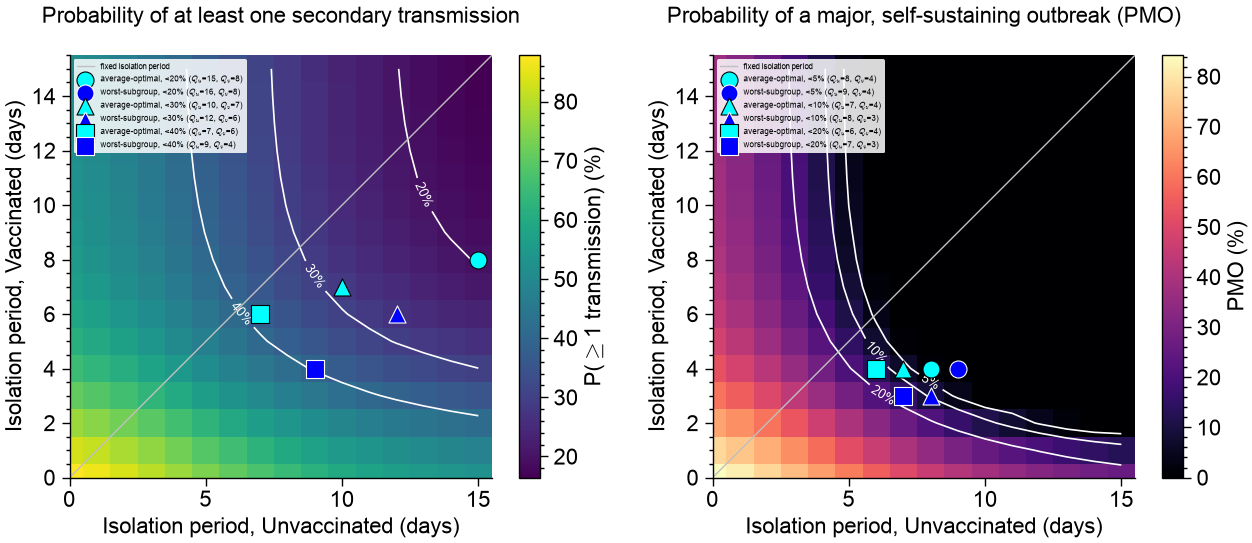

In [9]:
PROB_TRANSMIT_grid = (THETA_VAX_COHORT * np.nanmean(prob_any_transmission(R_v_i), axis=0)[None, :]
                       + (1 - THETA_VAX_COHORT) * np.nanmean(prob_any_transmission(R_u_i), axis=0)[:, None])
PMO_grid = pdf_pmo_2d_sampled(R_v_i, R_u_i, THETA_VAX_COHORT)

# per-group 1D curves, needed for the worst-subgroup-optimal overlay markers below
Pt_u_only = np.nanmean(prob_any_transmission(R_u_i), axis=0)
Pt_v_only = np.nanmean(prob_any_transmission(R_v_i), axis=0)
PMO_u_only = pdf_pmo_1d_sampled(R_v_i, R_u_i, 0.0)
PMO_v_only = pdf_pmo_1d_sampled(R_v_i, R_u_i, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, grid, metric_u, metric_v, cmap, title, cbar_label, letter, levels in [
    (axes[0], PROB_TRANSMIT_grid, Pt_u_only, Pt_v_only, "viridis", "Probability of at least one secondary transmission",
     r"P($\geq$1 transmission) (%)", "2a", [20, 30, 40]),
    (axes[1], PMO_grid, PMO_u_only, PMO_v_only, "magma", "Probability of a major, self-sustaining outbreak (PMO)",
     "PMO (%)", "2b", [5, 10, 20]),
]:
    # contour + clabel restricted to the visible Q<=15 window -- computing them over
    # the full Q_RANGE_FIX (0-30) places clabel's auto label positions beyond the
    # visible xlim, so labels silently fall outside the plotted area.
    Q_PLOT = Q_RANGE_FIX[Q_RANGE_FIX <= 15]
    grid_plot = grid[:len(Q_PLOT), :len(Q_PLOT)]
    im = ax.imshow(100 * grid_plot.T, origin="lower",
                    extent=[Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5,
                            Q_PLOT[0] - 0.5, Q_PLOT[-1] + 0.5],
                    aspect="equal", cmap=cmap)
    cs = ax.contour(Q_PLOT, Q_PLOT, 100 * grid_plot.T, levels=levels, colors="white", linewidths=1.2)
    ax.clabel(cs, fmt="%d%%", fontsize=9, inline=True)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, ls="-", label="fixed isolation period")

    for level, marker in zip(levels, MARKERS_2):
        result = combined_min_days(grid, level / 100.0, Q_RANGE_FIX)
        if result is not None:
            qu, qv, val = result
            ax.scatter(qu, qv, color="cyan", marker=marker, s=150, edgecolors="black", linewidths=0.8,
                       zorder=5, label=rf"average-optimal, <{level}% ($Q_u$={qu}, $Q_v$={qv})")
        worst = worst_subgroup_min_days(metric_u, metric_v, level / 100.0, Q_RANGE_FIX)
        if worst[0] is not None and worst[1] is not None:
            ax.scatter(worst[0], worst[1], color="blue", marker=marker, s=150, edgecolors="white", linewidths=0.8,
                       zorder=6, label=rf"worst-subgroup, <{level}% ($Q_u$={worst[0]}, $Q_v$={worst[1]})")

    ax.set_xlabel("Isolation period, Unvaccinated (days)")
    ax.set_ylabel("Isolation period, Vaccinated (days)")
    ax.set_xlim(0, 15.5)
    ax.set_ylim(0, 15.5)
    ax.set_title(rf"{title}" + "\n")
    fig.colorbar(im, ax=ax, label=cbar_label)
    ax.legend(frameon=True, fontsize=6, loc="upper left", framealpha=0.85, edgecolor="none")

# fig.suptitle("Plot 2: transmission and outbreak probability, independently swept isolation periods", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## Plot 3: residual post-release outbreak probability

Plot 2b's joint fixed point inherits branching-process criticality, so it goes flat once
$\mathcal R_{\text{eff}}<1$. This plot asks a different question instead: holding the ambient
population's own risk fixed, how much does releasing this one source on day $Q$ still add?
That question stays informative past the criticality cliff. It uses eq (7.2)'s
class-weighted-sum structure, applied per simulated patient:
$$P_s^{(\text{post})}(Q) = \text{mean}_i\Big[1-\exp\!\big(-R_{s,i}^{(\text{post})}(Q)\,p_{\text{out}}^{\text{ambient}}\big)\Big], \qquad p_{\text{out}}^{\text{ambient}}=p_{\text{out}}\big|_{Q_u=Q_v=0}$$

**Design choice:** each patient's own probability is computed first and then averaged, not
the reverse. Averaging $R_i$ across patients before applying the $1-e^{-x}$ transform gives a
different, and wrong, answer here. The two aren't interchangeable: $1-e^{-x}$ is concave, so
$\text{mean}_i(1-e^{-R_i})\le1-e^{-\text{mean}_i(R_i)}$ always, by Jensen's inequality.
Collapsing to the mean rate first would systematically overstate this probability.

**Limitation: offspring don't isolate either.** $p_{\text{out}}^{\text{ambient}}$ is itself a
fixed point of eq (7.1) evaluated at $Q_u=Q_v=0$. Because a fixed point is self-referential,
the same $q$ governs every generation. So this doesn't just mean the released person's first
secondary case fails to isolate: no generation, at any depth, ever isolates. Only the one
focal individual is held to the swept $Q$. The moment they transmit, that secondary case, and
everyone downstream of it, is indistinguishable from an ordinary ambient infection. This is a
deliberate simplification, not an oversight. If offspring also isolated under the same $Q$,
this would just reduce to Plot 2's joint fixed point again, with the same criticality cliff
Plot 3 exists to avoid. Read this plot as showing what isolating just this one person buys, in
a world that otherwise isn't isolating, not what happens if the policy applied to everyone
including their descendants. It has nothing to say about policies like contact tracing that
would isolate the offspring too.

**Both terms come from the sampled population, not a single trajectory.**
$R_{s,i}^{(\text{post})}(Q)$ is computed per patient, for every one of the roughly 1000
simulated patients (`Rpost_v_i`, `Rpost_u_i`), from that patient's own viral-load trajectory.
$P_s^{(\text{post})}(Q)$ then averages each patient's probability across their group.
$p_{\text{out}}^{\text{ambient}}$ works the same way: it's the same fixed-point average over
every simulated patient's own $R(Q{=}0)$, just evaluated at the "nobody isolates" point,
rather than a scalar plugged in from a representative trajectory. This is why the quantity
needs the per-patient-probability-then-average approach above. With a real heterogeneous
population sample, mean-rate-then-transform and mean-of-transformed-rates give different
numbers.


Ambient p_out (no isolation, theta=0.5) = 0.8425


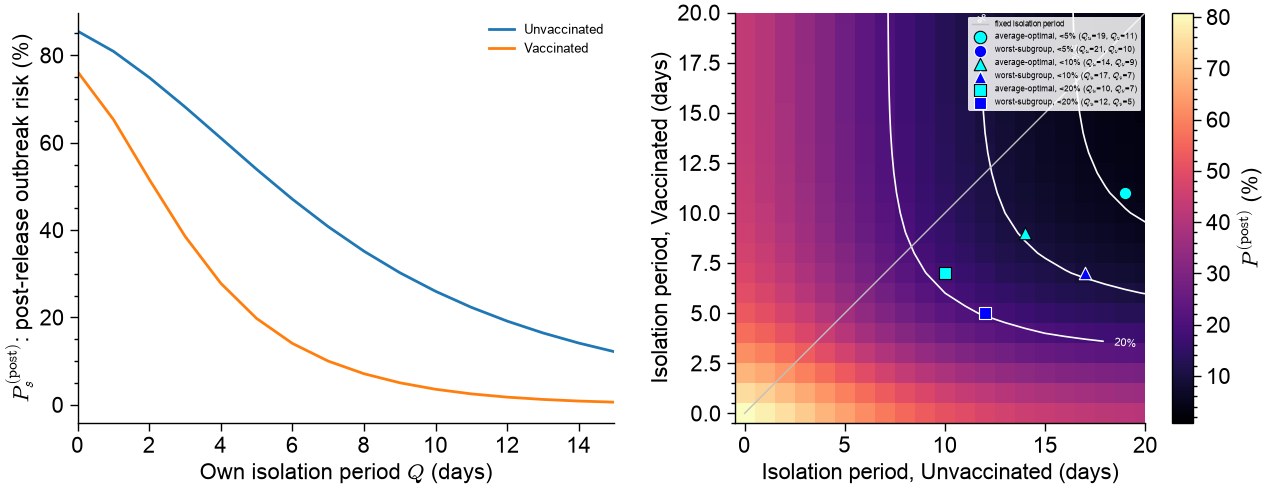

In [10]:
P_OUT_AMBIENT = pdf_pmo_1d_sampled(R_v_i[:, :1], R_u_i[:, :1], THETA_VAX_COHORT)[0]
print(f"Ambient p_out (no isolation, theta={THETA_VAX_COHORT}) = {P_OUT_AMBIENT:.4f}")

Rpost_v_mean = np.nanmean(Rpost_v_i, axis=0)
Rpost_u_mean = np.nanmean(Rpost_u_i, axis=0)

# Eq. 7.2: average each patient's OWN probability, not the mean rate transformed afterward
P_post_u = np.nanmean(1.0 - np.exp(-Rpost_u_i * P_OUT_AMBIENT), axis=0)
P_post_v = np.nanmean(1.0 - np.exp(-Rpost_v_i * P_OUT_AMBIENT), axis=0)
P_post_grid = (THETA_VAX_COHORT * P_post_v[None, :] + (1 - THETA_VAX_COHORT) * P_post_u[:, None])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.plot(Q_RANGE_FIX, 100 * P_post_u, color="tab:blue", lw=2, label="Unvaccinated")
ax.plot(Q_RANGE_FIX, 100 * P_post_v, color="tab:orange", lw=2, label="Vaccinated")
ax.set_xlabel("Own isolation period $Q$ (days)")
ax.set_ylabel(r"$P_s^{(\mathrm{post})}$: post-release outbreak risk (%)")
ax.set_xlim(0, 15)
# ax.set_title("3-left. Outbreak risk from post-release transmission, by own release day\n"
#              rf"(ambient risk fixed at {P_OUT_AMBIENT:.3f})", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
levels = [5, 10, 20]
im = ax.imshow(100 * P_post_grid.T, origin="lower",
                extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                        Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                aspect="equal", cmap="magma")
cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, 100 * P_post_grid.T, levels=levels, colors="white", linewidths=1.2)
ax.clabel(cs, fmt="%d%%", fontsize=8)
ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, label="fixed isolation period")
for level, marker in zip(levels, MARKERS_2):
    result = combined_min_days(P_post_grid, level / 100.0, Q_RANGE_FIX)
    if result is not None:
        qu, qv, val = result
        ax.scatter(qu, qv, color="cyan", marker=marker, s=80, edgecolors="black", linewidths=0.8,
                   zorder=5, label=rf"average-optimal, <{level}% ($Q_u$={qu}, $Q_v$={qv})")
    worst = worst_subgroup_min_days(P_post_u, P_post_v, level / 100.0, Q_RANGE_FIX)
    if worst[0] is not None and worst[1] is not None:
        ax.scatter(worst[0], worst[1], color="blue", marker=marker, s=80, edgecolors="white", linewidths=0.8,
                   zorder=6, label=rf"worst-subgroup, <{level}% ($Q_u$={worst[0]}, $Q_v$={worst[1]})")
ax.set_xlabel("Isolation period, Unvaccinated (days)")
ax.set_ylabel("Isolation period, Vaccinated (days)")
ax.set_xlim(-0.5, 20)
ax.set_ylim(-0.5, 20)
# ax.set_title(rf"3-right. Population-pooled post-release outbreak risk ($\theta$={THETA_VAX_COHORT})", fontsize=10.5)
fig.colorbar(im, ax=ax, label=r"$P^{(\mathrm{post})}$ (%)")
ax.legend(frameon=True, fontsize=6, loc="upper right", framealpha=0.85, edgecolor="none")

# fig.suptitle("Plot 3: outbreak risk attributable to transmission after release, ambient risk held fixed", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## Plot 4: effect of vaccination coverage

This sweeps $\theta\in[0,1]$ directly through the population-sampled grids. The population's
per-patient pools stay fixed; only the mixing weight $\theta$ changes, and it need not match
the actual simulated 50/50 split. For each coverage level and acceptable-risk threshold, we
compute the minimum $\theta$-weighted mean isolation burden:
$$\overline{Q}^*(\theta) = \min_{(Q_u,Q_v)\,:\,\text{grid}(Q_u,Q_v;\theta)<\text{thresh}} \big[(1-\theta)Q_u+\theta Q_v\big]$$


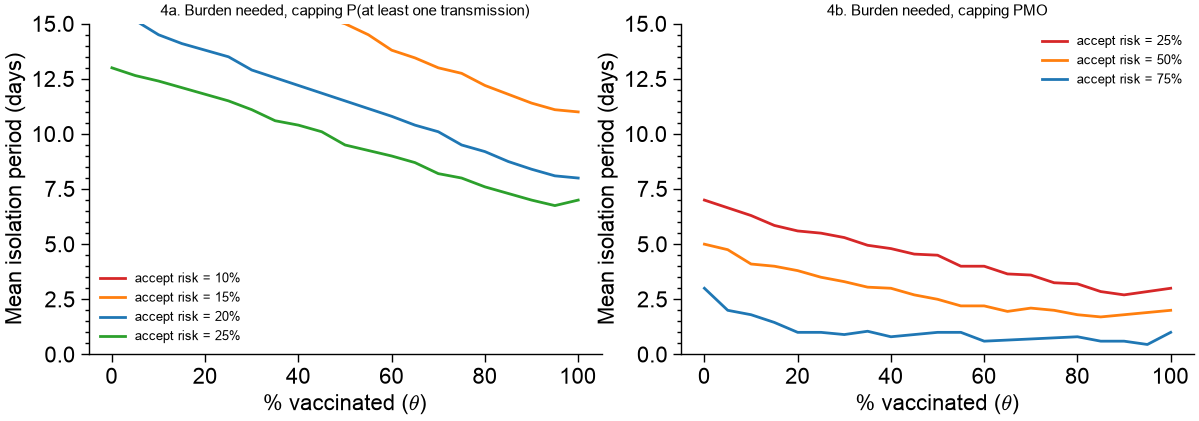

In [11]:
def best_Q_mean_days(grid, thresh, theta_g, Q_grid):
    feas = grid < thresh
    if not feas.any():
        return None
    mean_days = (1 - theta_g) * Q_grid[:, None] + theta_g * Q_grid[None, :]
    idx = np.unravel_index(np.argmin(np.where(feas, mean_days, np.inf)), grid.shape)
    return int(Q_grid[idx[0]]), int(Q_grid[idx[1]]), mean_days[idx]


THETA_SWEEP = np.linspace(0.0, 1.0, 21)
ACCEPT_RISK_SHOW = [0.10, 0.15, 0.20, 0.25]
ACCEPT_COLORS = ["tab:red", "tab:orange", "tab:blue", "tab:green"]
ACCEPT_RISK_SHOW_4B = [0.25, 0.50, 0.75]
ACCEPT_COLORS_4B = ["tab:red", "tab:orange", "tab:blue"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

ax = axes[0]
for risk, color in zip(ACCEPT_RISK_SHOW, ACCEPT_COLORS):
    curve = np.full(len(THETA_SWEEP), np.nan)
    for i, theta_g in enumerate(THETA_SWEEP):
        grid = (theta_g * np.nanmean(prob_any_transmission(R_v_i), axis=0)[None, :]
                + (1 - theta_g) * np.nanmean(prob_any_transmission(R_u_i), axis=0)[:, None])
        r = best_Q_mean_days(grid, risk, theta_g, Q_RANGE_FIX)
        if r is not None:
            curve[i] = r[2]
    ax.plot(100 * THETA_SWEEP, curve, color=color, lw=2, label=f"accept risk = {int(100*risk)}%")
ax.set_xlabel(r"% vaccinated ($\theta$)")
ax.set_ylabel("Mean isolation period (days)")
ax.set_title("4a. Burden needed, capping P(at least one transmission)", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
ax.set_ylim([0, 15])
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax = axes[1]
for risk, color in zip(ACCEPT_RISK_SHOW_4B, ACCEPT_COLORS_4B):
    curve = np.full(len(THETA_SWEEP), np.nan)
    for i, theta_g in enumerate(THETA_SWEEP):
        grid = pdf_pmo_2d_sampled(R_v_i, R_u_i, theta_g)
        r = best_Q_mean_days(grid, risk, theta_g, Q_RANGE_FIX)
        if r is not None:
            curve[i] = r[2]
    ax.plot(100 * THETA_SWEEP, curve, color=color, lw=2, label=f"accept risk = {int(100*risk)}%")
ax.set_xlabel(r"% vaccinated ($\theta$)")
ax.set_ylabel("Mean isolation period (days)")
ax.set_title("4b. Burden needed, capping PMO", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
ax.set_ylim([0, 15])
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# fig.suptitle("Plot 4: mean isolation-days needed to hit a target risk level, as vaccination coverage varies", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Plot 5: "protect the average" vs. "protect every subgroup"

`combined_min_days` constrains the pooled grid, which is an average-risk objective. The
alternative is stricter: both groups' own single-type risk ($\theta_g=0$ or $1$ in eq 7.1,
i.e. `pdf_pmo_1d_sampled` restricted to just that pool's patients) must individually clear
the threshold. `worst_subgroup_min_days` doesn't need a grid search for this: `metric_u`
depends only on $Q_u$ and `metric_v` only on $Q_v$, so the two constraints are independent 1D
crossings.


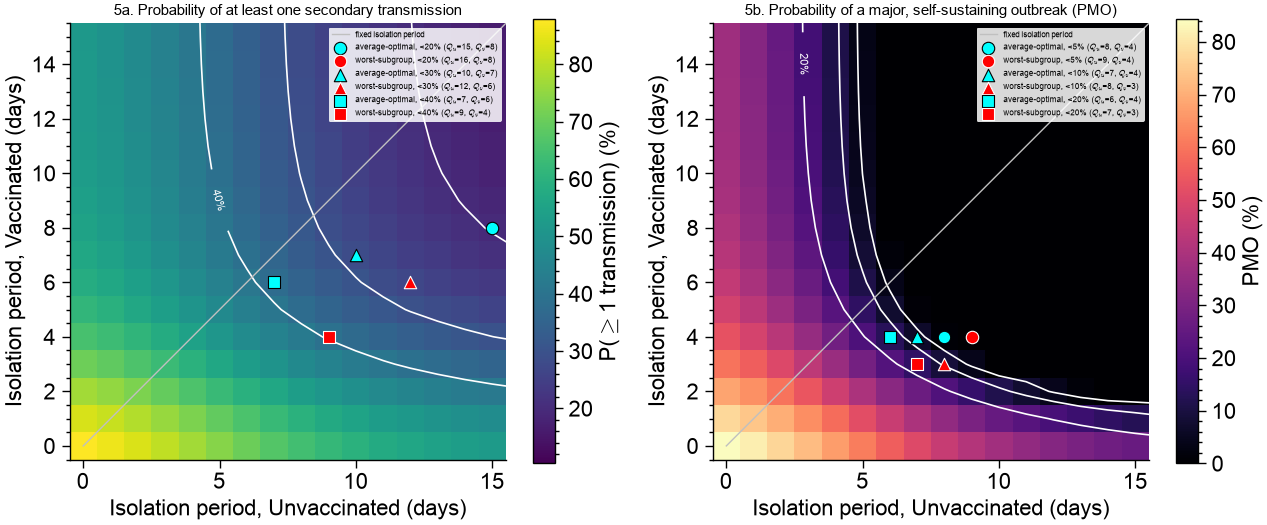

        metric   level    average (Qu,Qv,tot)   worst-subgroup (Qu,Qv,tot)
   P(transmit)  < 20%             (15,8,23d)                   (16,8,24d)
   P(transmit)  < 30%             (10,7,17d)                   (12,6,18d)
   P(transmit)  < 40%              (7,6,13d)                    (9,4,13d)
           PMO  <  5%              (8,4,12d)                    (9,4,13d)
           PMO  < 10%              (7,4,11d)                    (8,3,11d)
           PMO  < 20%              (6,4,10d)                    (7,3,10d)

What the average-constrained PMO optimum actually leaves each group exposed to:
PMO<5% average-optimal (Qu=8,Qv=4): pooled=0.80%  but PMO_u_only=9.95%  PMO_v_only=0.00%
PMO<10% average-optimal (Qu=7,Qv=4): pooled=6.59%  but PMO_u_only=19.89%  PMO_v_only=0.00%
PMO<20% average-optimal (Qu=6,Qv=4): pooled=13.23%  but PMO_u_only=31.20%  PMO_v_only=0.00%


In [12]:
PMO_u_only = pdf_pmo_1d_sampled(R_v_i, R_u_i, 0.0)
PMO_v_only = pdf_pmo_1d_sampled(R_v_i, R_u_i, 1.0)
Pt_u_only = np.nanmean(prob_any_transmission(R_u_i), axis=0)
Pt_v_only = np.nanmean(prob_any_transmission(R_v_i), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, grid, metric_u, metric_v, cmap, title, cbar_label, letter, levels in [
    (axes[0], PROB_TRANSMIT_grid, Pt_u_only, Pt_v_only, "viridis",
     "Probability of at least one secondary transmission", r"P($\geq$1 transmission) (%)", "5a", [20, 30, 40]),
    (axes[1], PMO_grid, PMO_u_only, PMO_v_only, "magma",
     "Probability of a major, self-sustaining outbreak (PMO)", "PMO (%)", "5b", [5, 10, 20]),
]:
    im = ax.imshow(100 * grid.T, origin="lower",
                    extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                            Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                    aspect="equal", cmap=cmap)
    cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, 100 * grid.T, levels=levels, colors="white", linewidths=1.2)
    ax.clabel(cs, fmt="%d%%", fontsize=8)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, label="fixed isolation period")

    for level, marker in zip(levels, MARKERS_2):
        thresh = level / 100.0
        avg = combined_min_days(grid, thresh, Q_RANGE_FIX)
        if avg is not None:
            ax.scatter(avg[0], avg[1], color="cyan", marker=marker, s=80, edgecolors="black",
                       linewidths=0.8, zorder=5, label=rf"average-optimal, <{level}% ($Q_u$={avg[0]}, $Q_v$={avg[1]})")
        worst = worst_subgroup_min_days(metric_u, metric_v, thresh, Q_RANGE_FIX)
        if worst[0] is not None and worst[1] is not None:
            ax.scatter(worst[0], worst[1], color="red", marker=marker, s=80, edgecolors="white",
                       linewidths=0.8, zorder=6, label=rf"worst-subgroup, <{level}% ($Q_u$={worst[0]}, $Q_v$={worst[1]})")

    ax.set_xlabel("Isolation period, Unvaccinated (days)")
    ax.set_ylabel("Isolation period, Vaccinated (days)")
    ax.set_xlim(-0.5, 15.5)
    ax.set_ylim(-0.5, 15.5)
    ax.set_title(f"{letter}. {title}", fontsize=10.5)
    fig.colorbar(im, ax=ax, label=cbar_label)
    ax.legend(frameon=True, fontsize=6, loc="upper right", framealpha=0.85, edgecolor="none")
    ax.tick_params(top=False, right=False)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# fig.suptitle("""Plot 5: pooled/average-constrained vs. worst-subgroup-constrained optimum
# (same risk surface, two different equity assumptions)""", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"{'metric':>14}  {'level':>6}  {'average (Qu,Qv,tot)':>21}  {'worst-subgroup (Qu,Qv,tot)':>27}")
for label, grid, metric_u, metric_v, levels in [
    ("P(transmit)", PROB_TRANSMIT_grid, Pt_u_only, Pt_v_only, [20, 30, 40]),
    ("PMO", PMO_grid, PMO_u_only, PMO_v_only, [5, 10, 20]),
]:
    for level in levels:
        thresh = level / 100.0
        avg = combined_min_days(grid, thresh, Q_RANGE_FIX)
        worst = worst_subgroup_min_days(metric_u, metric_v, thresh, Q_RANGE_FIX)
        avg_str = f"({avg[0]},{avg[1]},{avg[0] + avg[1]}d)" if avg else "infeasible"
        worst_str = (f"({worst[0]},{worst[1]},{worst[0] + worst[1]}d)"
                     if worst[0] is not None and worst[1] is not None else "infeasible")
        print(f"{label:>14}  <{level:>3}%  {avg_str:>21}  {worst_str:>27}")

print("\nWhat the average-constrained PMO optimum actually leaves each group exposed to:")
for level in [5, 10, 20]:
    thresh = level / 100.0
    avg = combined_min_days(PMO_grid, thresh, Q_RANGE_FIX)
    qu_idx, qv_idx = list(Q_RANGE_FIX).index(avg[0]), list(Q_RANGE_FIX).index(avg[1])
    print(f"PMO<{level}% average-optimal (Qu={avg[0]},Qv={avg[1]}): pooled={100 * avg[2]:.2f}%  "
          f"but PMO_u_only={100 * PMO_u_only[qu_idx]:.2f}%  PMO_v_only={100 * PMO_v_only[qv_idx]:.2f}%")

**Note.** At the average-constrained PMO$<10\%$ optimum ($Q_u=7,Q_v=4$, pooled $6.59\%$),
unvaccinated-alone risk is still $19.89\%$. That's a real masking effect: the pooled/average
constraint alone doesn't guarantee either subgroup individually clears the threshold.
Worst-subgroup-constrained needs $(Q_u{=}8,Q_v{=}3)=11$d total, the same total as
average-constrained's $11$d. The days are just reallocated, one day from vaccinated to
unvaccinated, at zero net cost.


## Plot 6: expected post-release secondary infections

$R_i^{(\text{post})}(Q)$ (eq 3.4) is already $E[N_i^{(\text{post})}]$, eq 6.2's Poisson mean.
Plot 3 only ever used it after converting to a probability (eq 6.4). Here we plot the raw
expected count directly. Unlike PMO or $P(\text{transmit})$, expected counts from independent
index cases add, which makes this the natural metric for capacity planning.


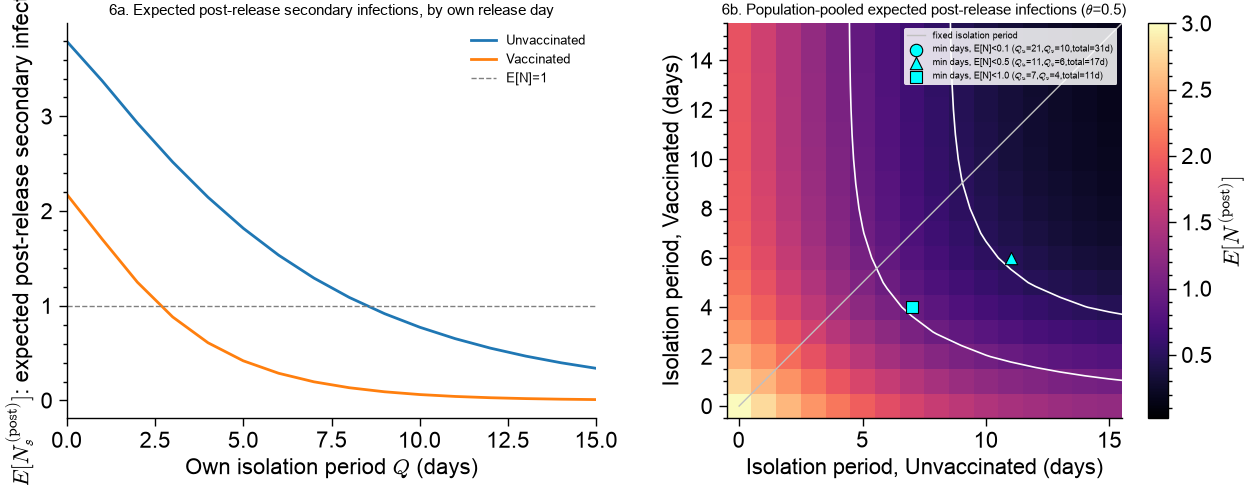

 threshold     Qu,Qv,total    pooled P_post (outbreak)    pooled P(>=1 post-release)
E[N]<1.0    (7,4,11d)                       34.2816%                       37.12%
E[N]<0.5    (11,6,17d)                       18.1708%                       19.86%
E[N]<0.1    (21,10,31d)                        4.2693%                        4.75%
E[N]<0.05   (26,12,38d)                        2.0991%                        2.35%


In [13]:
EN_grid = THETA_VAX_COHORT * Rpost_v_mean[None, :] + (1 - THETA_VAX_COHORT) * Rpost_u_mean[:, None]
Pt_post_grid = (THETA_VAX_COHORT * np.nanmean(prob_any_transmission(Rpost_v_i), axis=0)[None, :]
                + (1 - THETA_VAX_COHORT) * np.nanmean(prob_any_transmission(Rpost_u_i), axis=0)[:, None])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.plot(Q_RANGE_FIX, Rpost_u_mean, color="tab:blue", lw=2, label="Unvaccinated")
ax.plot(Q_RANGE_FIX, Rpost_v_mean, color="tab:orange", lw=2, label="Vaccinated")
ax.axhline(1.0, color="grey", lw=1.0, ls="--", label="E[N]=1")
ax.set_xlabel("Own isolation period $Q$ (days)")
ax.set_ylabel(r"$E[N_s^{(\mathrm{post})}]$: expected post-release secondary infections")
ax.set_xlim(0, 15)
ax.set_title("6a. Expected post-release secondary infections, by own release day", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax = axes[1]
levels = [0.1, 0.5, 1.0]
im = ax.imshow(EN_grid.T, origin="lower",
                extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                        Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                aspect="equal", cmap="magma", vmax=3)
cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, EN_grid.T, levels=levels, colors="white", linewidths=1.2)
ax.clabel(cs, fmt="%.1f", fontsize=8)
ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, label="fixed isolation period")
for level, marker in zip(levels, MARKERS_2):
    result = combined_min_days(EN_grid, level, Q_RANGE_FIX)
    if result is not None:
        qu, qv, val = result
        ax.scatter(qu, qv, color="cyan", marker=marker, s=80, edgecolors="black", linewidths=0.8,
                   zorder=5, label=rf"min days, E[N]<{level} ($Q_u$={qu},$Q_v$={qv},total={qu+qv}d)")
ax.set_xlabel("Isolation period, Unvaccinated (days)")
ax.set_ylabel("Isolation period, Vaccinated (days)")
ax.set_xlim(-0.5, 15.5)
ax.set_ylim(-0.5, 15.5)
ax.set_title(rf"6b. Population-pooled expected post-release infections ($\theta$={THETA_VAX_COHORT})", fontsize=10.5)
fig.colorbar(im, ax=ax, label=r"$E[N^{(\mathrm{post})}]$")
ax.legend(frameon=True, fontsize=6.5, loc="upper right", framealpha=0.85, edgecolor="none")
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# fig.suptitle("""Plot 6: expected post-release secondary infections (eq 3.4/6.2) -- an additive
# count, not a probability of outbreak or of any transmission""", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"{'threshold':>10}  {'Qu,Qv,total':>14}  {'pooled P_post (outbreak)':>26}  {'pooled P(>=1 post-release)':>28}")
for level in [1.0, 0.5, 0.1, 0.05]:
    r = combined_min_days(EN_grid, level, Q_RANGE_FIX)
    if r is not None:
        qu_idx, qv_idx = list(Q_RANGE_FIX).index(r[0]), list(Q_RANGE_FIX).index(r[1])
        print(f"E[N]<{level:<5}  ({r[0]},{r[1]},{r[0]+r[1]}d)      {100*P_post_grid[qu_idx,qv_idx]:24.4f}%  {100*Pt_post_grid[qu_idx,qv_idx]:26.2f}%")

**Note.** At the pooled $E[N^{(\text{post})}]<1$ optimum ($Q_u=7,Q_v=4$, $11$d), the
probability that post-release transmission still eventually seeds a major outbreak is
$34.28\%$ (`P_post_grid`, eq 7.2, each patient's own probability averaged, see Plot 3's
corrected computation). The probability of any post-release transmission at all is $37.12\%$.
So "expect fewer than one extra case on average" is still compatible with "roughly
one-in-three odds it blows up," though less starkly than a naive mean-rate shortcut would
suggest. Only at $E[N]<0.1$ ($Q_u=21,Q_v=10$, $31$d) does the outbreak probability fall to
$4.27\%$.

Per group, vaccinated patients cross $E[N]<1$ at $Q=2$ and $E[N]<0.5$ at $Q=3$; unvaccinated
need $Q=4$ and $Q=6$ respectively. That's the same roughly 2x gap seen throughout this
notebook, now expressed as a plain expected-case count rather than a probability. This is
probably the easier number to communicate to a non-technical audience: "expect about one
extra case" versus "a 63\% chance of at least one," the generic Poisson$(1)$ relationship
$1-e^{-1}$.


## Plot 7: relaxing $\varphi=1$ (100% isolation compliance)

This is the full eq (5.1) with $\varphi$ free, per patient. A $\varphi$ fraction of each
vaccination group isolates ($R_{s,i}^{(\text{iso})}(Q)$), and the remaining $(1-\varphi)$
never isolates, transmitting each patient's own full, unmitigated potential
($R_{s,i}^{(\text{iso})}(0)$) regardless of $Q$. As $Q\to\infty$, the floor
$\mathcal R_{\text{eff}}=(1-\varphi)\mathcal R_0$ crosses 1 at $\varphi^*=1-1/\mathcal R_0$.
Below $\varphi^*$, PMO can never reach zero.


phi=1 matches pdf_pmo_1d_sampled, max abs diff: 0.0
phi=0 is constant, matches Q=0 value: True
R0_ACTUAL=3.151  critical compliance phi* = 0.6826


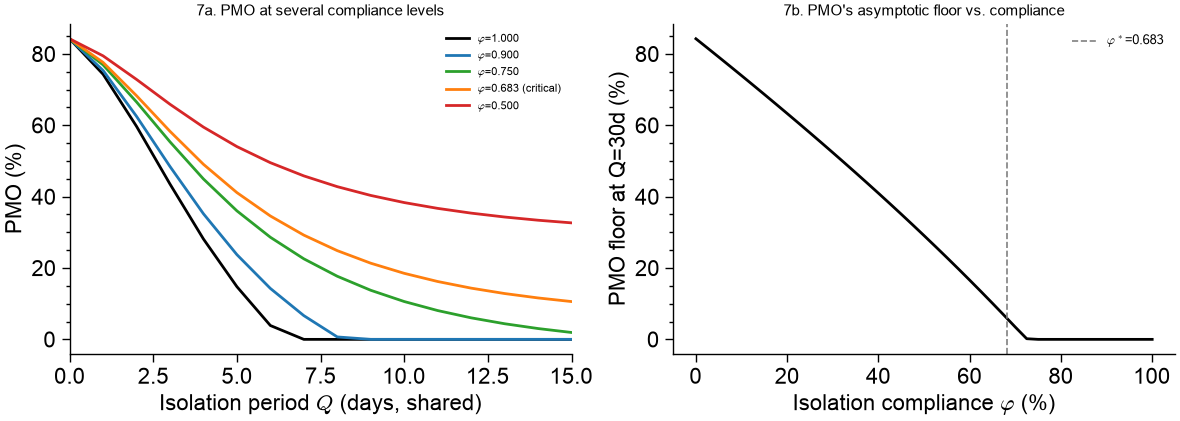

In [14]:
def pdf_pmo_1d_sampled_phi(R_v_i, R_u_i, theta_vax, phi, n_iter=300, tol=1e-8):
    Rv_full = R_v_i[:, :1]   # each patient's own Q=0 (full, unmitigated) R, (m_v,1)
    Ru_full = R_u_i[:, :1]
    n_Q = R_v_i.shape[1]
    q = np.zeros(n_Q)
    for _ in range(n_iter):
        one_minus_q = (1.0 - q)[None, :]
        g_v = np.nanmean(phi * np.exp(-R_v_i * one_minus_q) + (1 - phi) * np.exp(-Rv_full * one_minus_q), axis=0)
        g_u = np.nanmean(phi * np.exp(-R_u_i * one_minus_q) + (1 - phi) * np.exp(-Ru_full * one_minus_q), axis=0)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


_phi1_check = pdf_pmo_1d_sampled_phi(R_v_i, R_u_i, THETA_VAX_COHORT, phi=1.0)
print("phi=1 matches pdf_pmo_1d_sampled, max abs diff:", np.max(np.abs(_phi1_check - _oneD)))
_phi0_check = pdf_pmo_1d_sampled_phi(R_v_i, R_u_i, THETA_VAX_COHORT, phi=0.0)
print("phi=0 is constant, matches Q=0 value:", np.allclose(_phi0_check, _oneD[0]))

PHI_STAR = 1.0 - 1.0 / R0_ACTUAL
print(f"R0_ACTUAL={R0_ACTUAL:.3f}  critical compliance phi* = {PHI_STAR:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
PHI_SHOW = [1.0, 0.9, 0.75, PHI_STAR, 0.5]
PHI_COLORS = ["black", "tab:blue", "tab:green", "tab:orange", "tab:red"]
for phi, color in zip(PHI_SHOW, PHI_COLORS):
    curve = pdf_pmo_1d_sampled_phi(R_v_i, R_u_i, THETA_VAX_COHORT, phi)
    label = rf"$\varphi$={phi:.3f}" + (" (critical)" if abs(phi - PHI_STAR) < 1e-9 else "")
    ax.plot(Q_RANGE_FIX, 100 * curve, color=color, lw=2, label=label)
ax.set_xlabel("Isolation period $Q$ (days, shared)")
ax.set_ylabel("PMO (%)")
ax.set_xlim(0, 15)
ax.set_title("7a. PMO at several compliance levels", fontsize=10.5)
ax.legend(frameon=False, fontsize=8)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax = axes[1]
PHI_SWEEP = np.linspace(0.0, 1.0, 41)
floors = np.array([pdf_pmo_1d_sampled_phi(R_v_i, R_u_i, THETA_VAX_COHORT, phi)[-1] for phi in PHI_SWEEP])
ax.plot(100 * PHI_SWEEP, 100 * floors, color="black", lw=2)
ax.axvline(100 * PHI_STAR, color="grey", ls="--", lw=1.2, label=rf"$\varphi^*$={PHI_STAR:.3f}")
ax.set_xlabel(r"Isolation compliance $\varphi$ (%)")
ax.set_ylabel(f"PMO floor at Q={Q_RANGE_FIX[-1]}d (%)")
ax.set_title("7b. PMO's asymptotic floor vs. compliance", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# fig.suptitle("Plot 7: below a critical compliance level, longer isolation cannot bring PMO to zero", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Note.** $\varphi^*=1-1/\mathcal R_0=0.683$ here.

- **Design choice:** the critical-compliance floor is a purely aggregate, scalar property of
  $\mathcal R_0$ and $\theta$. Population sampling doesn't change why it exists, only which
  $\mathcal R_0$ it gets evaluated at (here, the population mean).


## Plot 7b: non-isolation sweep

This reframes Plot 7's $\varphi$-relaxation more generally, as the portion who do not isolate
for any reason. That covers imperfect compliance among symptomatic or detected people, not
just non-detection of asymptomatic cases. It also drops the asymptomatic-specific
infectiousness discount $\rho$ entirely: someone who doesn't isolate uses their own ordinary
$R_i$, with no claim needed about why they didn't isolate or whether they're systematically
more or less infectious.

$$q(Q_u,Q_v) = \theta\Big[\varphi\,\text{mean}_i\big(e^{-R_{v,i}(Q_v)(1-q)}\big) + (1-\varphi)\,\text{mean}_i\big(e^{-R_{v,i}(0)(1-q)}\big)\Big] + (1-\theta)\Big[\varphi\,\text{mean}_i\big(e^{-R_{u,i}(Q_u)(1-q)}\big) + (1-\varphi)\,\text{mean}_i\big(e^{-R_{u,i}(0)(1-q)}\big)\Big]$$
$$\text{PMO}(Q_u,Q_v;\varphi) = 1-q(Q_u,Q_v;\varphi)$$

**Design choice:** $\varphi=1$, everyone isolates, reproduces the ordinary `PMO_grid`
(Plot 2b) exactly, checked below. Sweeping $\varphi$ down shows how much of the isolation
policy's protection a given non-isolating fraction erodes, now swept jointly over $(Q_u,Q_v)$
rather than the shared-$Q$ 1D sweep Plot 7 already covers.


phi=1 matches PMO_grid, max abs diff: 0.0


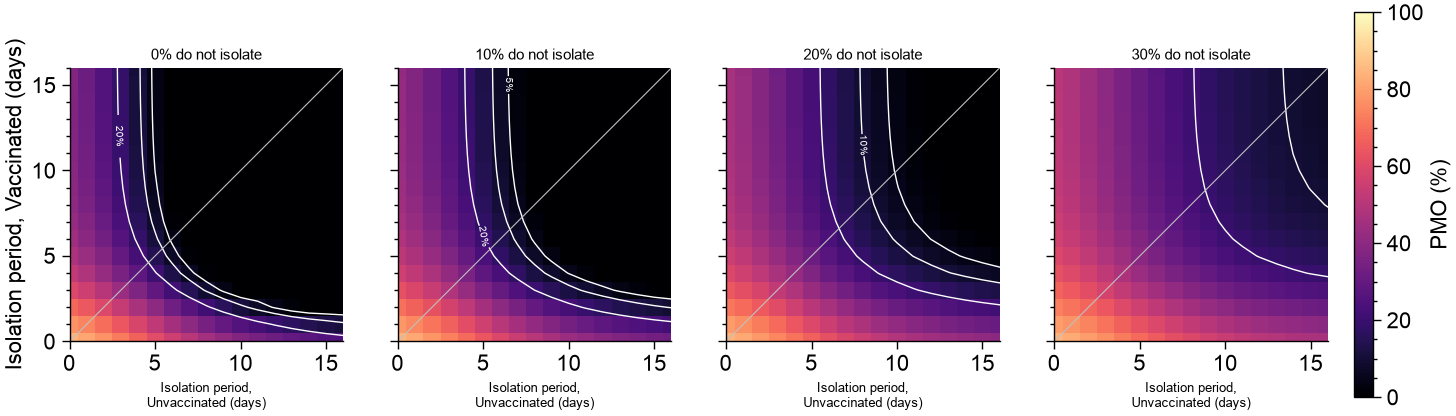

In [15]:
def pdf_pmo_2d_sampled_phi(R_v_i, R_u_i, theta_vax, phi, n_iter=300, tol=1e-8):
    """eq (5.1) with phi free, independent (Q_u,Q_v) grid -- full 3-way Picard iteration,
    same construction as pdf_pmo_2d_sampled (cell above) with Plot 7's phi-mixing added."""
    Rv_full = R_v_i[:, :1]
    Ru_full = R_u_i[:, :1]
    n_Q = R_v_i.shape[1]
    q = np.zeros((n_Q, n_Q))
    for _ in range(n_iter):
        one_minus_q = (1.0 - q)[:, :, None]
        Rv_iso_b = R_v_i.T[None, :, :]
        Rv_full_b = Rv_full[:, 0][None, None, :]
        g_v = np.nanmean(phi * np.exp(-Rv_iso_b * one_minus_q) + (1 - phi) * np.exp(-Rv_full_b * one_minus_q), axis=2)
        Ru_iso_b = R_u_i.T[:, None, :]
        Ru_full_b = Ru_full[:, 0][None, None, :]
        g_u = np.nanmean(phi * np.exp(-Ru_iso_b * one_minus_q) + (1 - phi) * np.exp(-Ru_full_b * one_minus_q), axis=2)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


NONISO_FRACS = [0.0, 0.10, 0.20, 0.30]   # 1 - phi
PHI_VALUES = [1.0 - f for f in NONISO_FRACS]

_check = pdf_pmo_2d_sampled_phi(R_v_i, R_u_i, THETA_VAX_COHORT, phi=1.0)
print("phi=1 matches PMO_grid, max abs diff:", np.max(np.abs(_check - PMO_grid)))

grids_phi = [pdf_pmo_2d_sampled_phi(R_v_i, R_u_i, THETA_VAX_COHORT, phi=phi) for phi in PHI_VALUES]

fig, axes = plt.subplots(1, 4, figsize=(17, 5), sharey=True)
levels_sweep = [5, 10, 20]
for ax, frac, grid in zip(axes, NONISO_FRACS, grids_phi):
    im = ax.imshow(100 * grid.T, origin="lower",
                    extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                            Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                    aspect="equal", cmap="magma", vmin=0, vmax=100)
    cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, 100 * grid.T, levels=levels_sweep,
                     colors="white", linewidths=1.0)
    ax.clabel(cs, fmt="%d%%", fontsize=7, inline=True)
    ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=0.8)
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 16)
    ax.set_xlabel("Isolation period,\nUnvaccinated (days)", fontsize=9.5)
    ax.set_title(f"{int(100*frac)}% do not isolate", fontsize=11)
axes[0].set_ylabel("Isolation period, Vaccinated (days)")
fig.colorbar(im, ax=axes, label="PMO (%)", fraction=0.025, pad=0.02)
# fig.suptitle("Effect of imperfect isolation compliance on outbreak risk", fontsize=13, y=1.03)
plt.show()


## Plot 8: excess isolation burden (economic cost)

This is the project's excess-burden metric,
$EX(Q)=\text{mean}(\max(Q-t_{\text{last infectious}},0))$, computed directly from the
simulated population using a hard Ct=25 (log10 6.11) threshold, rather than the continuous
Hill-function infectiousness used for PMO throughout. Burden needs a "still shedding or not"
cutoff, not a transmission rate.

**Design choice:** Ct=25 matches Ejima et al.'s own `4_Guideline.R` isolation-release
threshold. We kept it here so the burden metric is directly comparable to their published
methodology.


Infectious period (Ct25): unvaccinated mean=10.23d median=9d   vaccinated mean=5.44d median=5d


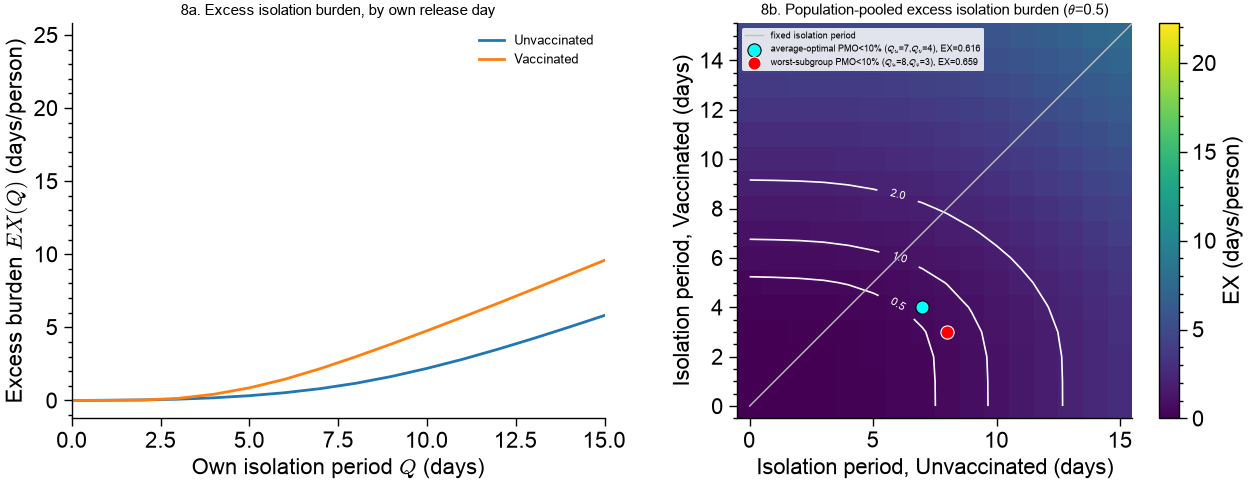

In [16]:
CT25_LOG10 = 6.11
logV_pop_fwd = logV_pop_full[:, IDX0:]
infectious = logV_pop_fwd >= CT25_LOG10
infectious_period = infectious.sum(axis=1)
ip_u, ip_v = infectious_period[~vac_mask], infectious_period[vac_mask]
print(f"Infectious period (Ct25): unvaccinated mean={ip_u.mean():.2f}d median={np.median(ip_u):.0f}d   "
      f"vaccinated mean={ip_v.mean():.2f}d median={np.median(ip_v):.0f}d")


def excess_burden(infectious_period_group, Q_values):
    return np.array([np.mean(np.maximum(Q - infectious_period_group, 0.0)) for Q in Q_values])


EX_u = excess_burden(ip_u, Q_RANGE_FIX)
EX_v = excess_burden(ip_v, Q_RANGE_FIX)
EX_grid = THETA_VAX_COHORT * EX_v[None, :] + (1 - THETA_VAX_COHORT) * EX_u[:, None]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.plot(Q_RANGE_FIX, EX_u, color="tab:blue", lw=2, label="Unvaccinated")
ax.plot(Q_RANGE_FIX, EX_v, color="tab:orange", lw=2, label="Vaccinated")
ax.set_xlabel("Own isolation period $Q$ (days)")
ax.set_ylabel("Excess burden $EX(Q)$ (days/person)")
ax.set_xlim(0, 15)
ax.set_title("8a. Excess isolation burden, by own release day", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax = axes[1]
im = ax.imshow(EX_grid.T, origin="lower",
                extent=[Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5,
                        Q_RANGE_FIX[0] - 0.5, Q_RANGE_FIX[-1] + 0.5],
                aspect="equal", cmap="viridis")
cs = ax.contour(Q_RANGE_FIX, Q_RANGE_FIX, EX_grid.T, levels=[0.5, 1, 2], colors="white", linewidths=1.2)
ax.clabel(cs, fmt="%.1f", fontsize=8)
ax.plot(Q_RANGE_FIX, Q_RANGE_FIX, color="silver", lw=1.0, label="fixed isolation period")
avg = combined_min_days(PMO_grid, 0.10, Q_RANGE_FIX)
worst = worst_subgroup_min_days(PMO_u_only, PMO_v_only, 0.10, Q_RANGE_FIX)
qu_idx, qv_idx = list(Q_RANGE_FIX).index(avg[0]), list(Q_RANGE_FIX).index(avg[1])
ax.scatter(avg[0], avg[1], color="cyan", marker="o", s=90, edgecolors="black", linewidths=0.8,
           zorder=5, label=rf"average-optimal PMO<10% ($Q_u$={avg[0]},$Q_v$={avg[1]}), EX={EX_grid[qu_idx,qv_idx]:.3f}")
qu_idx, qv_idx = list(Q_RANGE_FIX).index(worst[0]), list(Q_RANGE_FIX).index(worst[1])
ax.scatter(worst[0], worst[1], color="red", marker="o", s=90, edgecolors="white", linewidths=0.8,
           zorder=6, label=rf"worst-subgroup PMO<10% ($Q_u$={worst[0]},$Q_v$={worst[1]}), EX={EX_grid[qu_idx,qv_idx]:.3f}")
ax.set_xlabel("Isolation period, Unvaccinated (days)")
ax.set_ylabel("Isolation period, Vaccinated (days)")
ax.set_xlim(-0.5, 15.5)
ax.set_ylim(-0.5, 15.5)
ax.set_title(rf"8b. Population-pooled excess isolation burden ($\theta$={THETA_VAX_COHORT})", fontsize=10.5)
fig.colorbar(im, ax=ax, label="EX (days/person)")
ax.legend(frameon=True, fontsize=6.5, loc="upper left", framealpha=0.85, edgecolor="none")
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# fig.suptitle("""Plot 8: excess isolation burden -- the economic-cost side of the Qu,Qv tradeoff
# already explored (risk-side) in Plots 2/4/5""", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Note.** Vaccinated patients clear faster (median $5$d vs. $9$d), so isolating them for a
shared $Q$ wastes proportionally more of their time. Excess burden runs opposite to risk.

- **Design choice:** the hard Ct25 threshold is unaffected by the $\kappa$-calibration choice
  used for PMO, since it doesn't depend on the Hill-function scale at all. Excess burden and
  PMO are calibrated independently, by construction.


## Plot 9: relaxing $\eta=1$ (no acquisition-side vaccine effect)

Every plot above models only the transmission side of vaccination. eq (2.3)-(2.5)'s $\eta$,
vaccinated recipients' relative susceptibility to acquiring infection, is locked at $1$
because Ejima et al.'s NLME fit has no acquisition-side covariate. This sweep is illustrative
only, not a sourced efficacy-against-acquisition estimate.
$$q = a_v\,\text{mean}_i\,e^{-\bar\eta R_{v,i}^{(\text{iso})}(Q)(1-q)} + a_u\,\text{mean}_i\,e^{-\bar\eta R_{u,i}^{(\text{iso})}(Q)(1-q)}$$
with $\bar\eta=\theta\eta+(1-\theta)$, $a_v=\theta\eta/\bar\eta$, $a_u=(1-\theta)/\bar\eta$
(eq 2.3-2.5). Because $\theta=0.5$ of this cohort is unvaccinated regardless of $\eta$,
$\bar\eta\geq(1-\theta)=0.5$ always. Even perfect sterilizing immunity ($\eta\to0$) caps
population-level $\mathcal R_0$ reduction at $50\%$.


eta=1 matches pdf_pmo_1d_sampled, max abs diff: 0.0


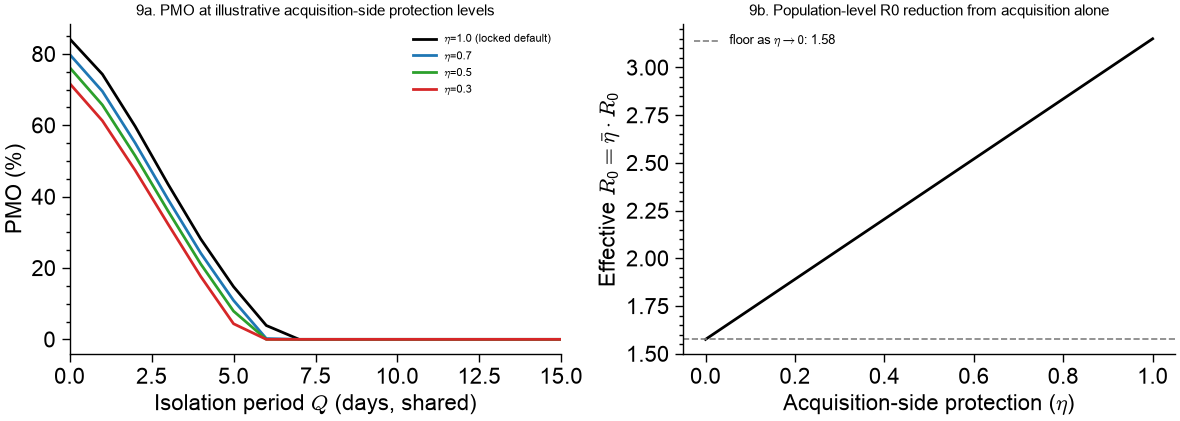

  eta   eta_bar   effective R0   min Q, PMO<10%
 1.00     1.000          3.151                6
 0.70     0.850          2.678                6
 0.50     0.750          2.363                5
 0.30     0.650          2.048                5


In [17]:
def pdf_pmo_1d_sampled_eta(R_v_i, R_u_i, theta_vax, eta, n_iter=300, tol=1e-8):
    eta_bar = theta_vax * eta + (1 - theta_vax)
    a_v = theta_vax * eta / eta_bar
    a_u = (1 - theta_vax) / eta_bar
    n_Q = R_v_i.shape[1]
    q = np.zeros(n_Q)
    for _ in range(n_iter):
        one_minus_q = (1.0 - q)[None, :]
        g_v = np.nanmean(np.exp(-eta_bar * R_v_i * one_minus_q), axis=0)
        g_u = np.nanmean(np.exp(-eta_bar * R_u_i * one_minus_q), axis=0)
        new_q = a_v * g_v + a_u * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


_eta1_check = pdf_pmo_1d_sampled_eta(R_v_i, R_u_i, THETA_VAX_COHORT, eta=1.0)
print("eta=1 matches pdf_pmo_1d_sampled, max abs diff:", np.max(np.abs(_eta1_check - _oneD)))

ETA_SHOW = [1.0, 0.7, 0.5, 0.3]
ETA_COLORS = ["black", "tab:blue", "tab:green", "tab:red"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
for eta, color in zip(ETA_SHOW, ETA_COLORS):
    curve = pdf_pmo_1d_sampled_eta(R_v_i, R_u_i, THETA_VAX_COHORT, eta)
    label = rf"$\eta$={eta:.1f}" + (" (locked default)" if eta == 1.0 else "")
    ax.plot(Q_RANGE_FIX, 100 * curve, color=color, lw=2, label=label)
ax.set_xlabel("Isolation period $Q$ (days, shared)")
ax.set_ylabel("PMO (%)")
ax.set_xlim(0, 15)
ax.set_title("9a. PMO at illustrative acquisition-side protection levels", fontsize=10.5)
ax.legend(frameon=False, fontsize=8)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax = axes[1]
ETA_SWEEP = np.linspace(0.0, 1.0, 41)
eta_bar_sweep = THETA_VAX_COHORT * ETA_SWEEP + (1 - THETA_VAX_COHORT)
ax.plot(ETA_SWEEP, eta_bar_sweep * R0_ACTUAL, color="black", lw=2)
floor = (1 - THETA_VAX_COHORT) * R0_ACTUAL
ax.axhline(floor, color="grey", ls="--", lw=1.2, label=rf"floor as $\eta\to0$: {floor:.2f}")
ax.set_xlabel(r"Acquisition-side protection ($\eta$)")
ax.set_ylabel(r"Effective $R_0=\bar\eta\cdot R_0$")
ax.set_title("9b. Population-level R0 reduction from acquisition alone", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# fig.suptitle("Plot 9: illustrative sensitivity sweep, not a sourced empirical estimate", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"{'eta':>5}  {'eta_bar':>8}  {'effective R0':>13}  {'min Q, PMO<10%':>15}")
for eta in ETA_SHOW:
    eta_bar = THETA_VAX_COHORT * eta + (1 - THETA_VAX_COHORT)
    curve = pdf_pmo_1d_sampled_eta(R_v_i, R_u_i, THETA_VAX_COHORT, eta)
    below = Q_RANGE_FIX[curve < 0.10].min() if (curve < 0.10).any() else None
    print(f"{eta:5.2f}  {eta_bar:8.3f}  {eta_bar*R0_ACTUAL:13.3f}  {str(below):>15}")

**Note.** The minimum $Q$ for PMO$<10\%$ stays at $6$d from $\eta=1$ through $\eta=0.7$,
then drops to $5$d at $\eta=0.5$ and below. It's a muted effect: the long isolation-duration
tail is far less sensitive to a uniform $\bar\eta$ rescaling than to the underlying
group-level $R$ gap. The structural $(1-\theta)$ floor on $\bar\eta$ (Plot 9b) still applies,
regardless of which $\mathcal R_0$ it's anchored to.


## Plot 10: asymptomatic infection, $\rho$ sweep and vaccination-stratified fraction

The PDF's own $\S9$ extensions list names this directly. Asymptomatic infections are never
tested, so they're never detected and never isolate under any policy $Q$. Unlike the
$\varphi$-noncompliant fraction, which shares the same viral-load profile as compliant cases,
asymptomatic infections may transmit at a systematically different rate $\rho$ relative to a
symptomatic case of the same vaccination status. $\rho=1$ means equally infectious, $\rho=0$
means non-infectious (silent, zero onward transmission), and intermediate $\rho$ means
partially infectious, which is what several empirical COVID studies suggest for genuinely
asymptomatic (not just pre-symptomatic) shedding.

**General 6-type mixture, per vaccination group $s\in\{v,u\}$**, extending Plot 7's 2-type
$\varphi$ mixture with a third type:

| type | population weight | transmits |
|---|---|---|
| isolating, compliant, symptomatic | $(1-x_s)\varphi$ | $R_{s,i}^{(\text{iso})}(Q_s)$ |
| non-compliant, symptomatic | $(1-x_s)(1-\varphi)$ | $R_{s,i}^{(\text{iso})}(0)$ (full, never isolates) |
| asymptomatic | $x_s$ | $\rho\,R_{s,i}^{(\text{iso})}(0)$ (full $\times\rho$, never isolates) |

$$q = \theta\Big[\text{mean}_i\big[(1-x_v)\varphi\,e^{-R_{v,i}^{(\text{iso})}(Q_v)(1-q)} + (1-x_v)(1-\varphi)\,e^{-R_{v,i}^{(\text{iso})}(0)(1-q)} + x_v\,e^{-\rho R_{v,i}^{(\text{iso})}(0)(1-q)}\big]\Big] + (1-\theta)\big[\ldots u\ldots\big], \quad \text{PMO}=1-q$$

**Why offspring don't need special bookkeeping for their founder's type.** This follows the
same logic established for $\varphi$ earlier in this notebook. eq (4.1)'s "typical infection"
branching structure redraws every generation's type independently from the population
mixture, so an asymptomatic founder's offspring are symptomatic or asymptomatic with the same
population probabilities $x_v,x_u$ as any other lineage. No multi-generation tracking of "was
my parent asymptomatic" is required. The single fixed point above already accounts for it.

**Exact reduction at $\rho=1$.** When asymptomatic cases are exactly as infectious as
symptomatic ones, the "non-compliant" and "asymptomatic" rows become identical: both transmit
the full, unmitigated $R_{s,i}^{(\text{iso})}(0)$ regardless of $Q$. They collapse into one
"never isolates" weight of $(1-x_s)(1-\varphi)+x_s = 1-(1-x_s)\varphi$. In other words, this
reduces exactly to Plot 7's $\varphi$-mixture with $\varphi_{\text{eff}}=(1-x_s)\varphi$,
verified below to machine precision.

**Critical asymptomatic fraction.** As $Q\to\infty$ with $\varphi=1$, the isolating
fraction's contribution vanishes, by the same argument as Plot 7's $\varphi^*$ floor,
leaving
$$\mathcal R_{\text{eff}}^{\text{floor}} = \rho\big[\theta\,x_v\,\bar B_v + (1-\theta)\,x_u\,\bar B_u\big]$$
In the symmetric case ($x_v=x_u=x$, $\rho=1$), the floor is $x\cdot\mathcal R_0$, crossing $1$
at $x^*=1/\mathcal R_0$. For this population, $x^*\approx0.317$. If more than about 32% of
infections are asymptomatic, split evenly across groups at full relative infectiousness,
isolation policy alone cannot drive the outbreak probability to zero, no matter how long it
runs.

**Illustrative parameters, not sourced estimates.** $x_u=0.20$ and $x_v=0.40$ mean vaccinated
infections are twice as likely to be asymptomatic as unvaccinated, matching the qualitative
direction reported in parts of the broader COVID literature. These values and the $\rho$
sweep below are chosen only to explore the qualitative shape of the interaction. Ejima et
al.'s NLME fit is to symptomatic Delta cases by construction, so neither this project's data
nor theirs can estimate $x_v,x_u,\rho$ directly. This has the same illustrative-only status
as the $\varphi$ and $\eta$ sweeps above.


x_v=x_u=0 matches pdf_pmo_1d_sampled, max abs diff: 0.0
rho=1, x_v=x_u=0.3 matches pdf_pmo_1d_sampled_phi(phi=0.7), max abs diff: 1.3322676295501878e-15


2D diagonal matches 1D, max abs diff: 2.220446049250313e-15
Symmetric critical fraction x* = 1/R0_ACTUAL = 0.3174


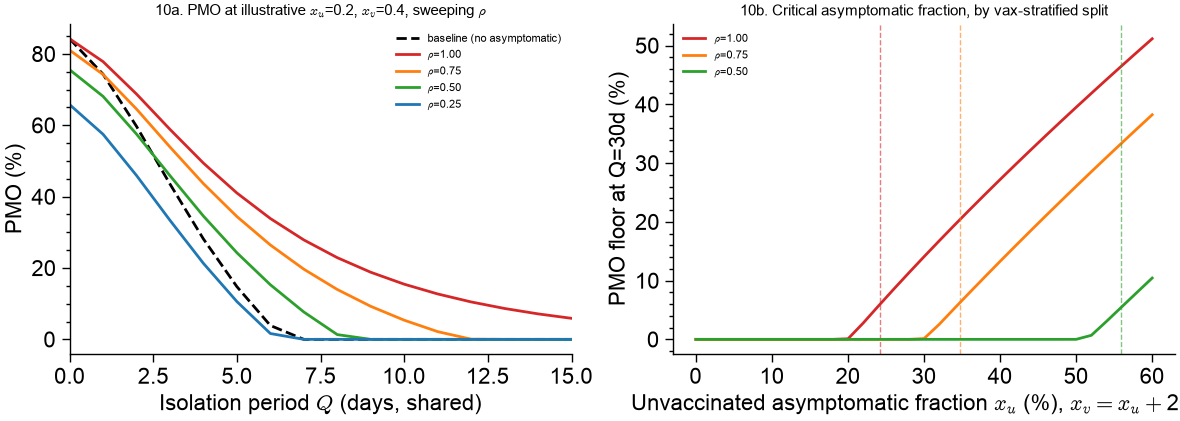


  rho   PMO(Q=0)   PMO(Q=8)   floor(Q=30)
 1.00     84.25%     22.90%       0.0952%


 0.75     81.07%     13.98%       0.0000%
 0.50     75.58%      1.33%       0.0000%


 0.25     65.80%      0.00%       0.0000%
 base     84.25%      0.00%       0.0000%  (x=0)

  rho   closed-form x_u*   closed-form x_v*
 1.00             0.2416             0.4416
 0.75             0.3474             0.5474
 0.50             0.5590             0.7590


In [18]:
def pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, theta_vax, x_v, x_u, rho, phi=1.0, n_iter=300, tol=1e-8):
    """General 6-type mixture (per-patient, shared Q axis): each vax group splits into
    (1-x)*phi isolating-compliant-symptomatic, (1-x)*(1-phi) non-compliant-symptomatic
    (transmits full, unmitigated B_i regardless of Q), and x asymptomatic (never isolates,
    transmits rho*B_i). x_v, x_u independent -- vaccination-stratified."""
    Rv_full = R_v_i[:, :1]
    Ru_full = R_u_i[:, :1]
    n_Q = R_v_i.shape[1]
    q = np.zeros(n_Q)
    for _ in range(n_iter):
        omq = (1.0 - q)[None, :]
        g_v = np.nanmean((1 - x_v) * phi * np.exp(-R_v_i * omq)
                          + (1 - x_v) * (1 - phi) * np.exp(-Rv_full * omq)
                          + x_v * np.exp(-rho * Rv_full * omq), axis=0)
        g_u = np.nanmean((1 - x_u) * phi * np.exp(-R_u_i * omq)
                          + (1 - x_u) * (1 - phi) * np.exp(-Ru_full * omq)
                          + x_u * np.exp(-rho * Ru_full * omq), axis=0)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


def pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, theta_vax, x_v, x_u, rho, phi=1.0, n_iter=300, tol=1e-8):
    """Same, independent (Q_u,Q_v) grid -- full 3-way Picard iteration."""
    Rv_full = R_v_i[:, :1]
    Ru_full = R_u_i[:, :1]
    n_Q = R_v_i.shape[1]
    q = np.zeros((n_Q, n_Q))
    for _ in range(n_iter):
        omq = (1.0 - q)[:, :, None]
        Rv_iso_b = R_v_i.T[None, :, :]
        Rv_full_b = Rv_full[:, 0][None, None, :]
        g_v = np.nanmean((1 - x_v) * phi * np.exp(-Rv_iso_b * omq)
                          + (1 - x_v) * (1 - phi) * np.exp(-Rv_full_b * omq)
                          + x_v * np.exp(-rho * Rv_full_b * omq), axis=2)
        Ru_iso_b = R_u_i.T[:, None, :]
        Ru_full_b = Ru_full[:, 0][None, None, :]
        g_u = np.nanmean((1 - x_u) * phi * np.exp(-Ru_iso_b * omq)
                          + (1 - x_u) * (1 - phi) * np.exp(-Ru_full_b * omq)
                          + x_u * np.exp(-rho * Ru_full_b * omq), axis=2)
        new_q = theta_vax * g_v + (1 - theta_vax) * g_u
        if np.max(np.abs(new_q - q)) < tol:
            q = new_q
            break
        q = new_q
    return 1.0 - q


_asymp0_check = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, x_v=0.0, x_u=0.0, rho=1.0)
print("x_v=x_u=0 matches pdf_pmo_1d_sampled, max abs diff:", np.max(np.abs(_asymp0_check - _oneD)))

_x_test = 0.3
_asymp_phi_check = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, x_v=_x_test, x_u=_x_test, rho=1.0)
_phi_equiv_check = pdf_pmo_1d_sampled_phi(R_v_i, R_u_i, THETA_VAX_COHORT, phi=(1 - _x_test))
print("rho=1, x_v=x_u=0.3 matches pdf_pmo_1d_sampled_phi(phi=0.7), max abs diff:",
      np.max(np.abs(_asymp_phi_check - _phi_equiv_check)))

_diag_check = np.diagonal(pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, x_v=0.4, x_u=0.2, rho=0.5))
_oneD_asymp_check = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, x_v=0.4, x_u=0.2, rho=0.5)
print("2D diagonal matches 1D, max abs diff:", np.max(np.abs(_diag_check - _oneD_asymp_check)))

X_U_ILLUS, X_V_ILLUS = 0.20, 0.40   # illustrative only -- see markdown above
B_v_mean, B_u_mean = np.nanmean(R_v_i[:, 0]), np.nanmean(R_u_i[:, 0])
X_STAR_SYMMETRIC = 1.0 / R0_ACTUAL
print(f"Symmetric critical fraction x* = 1/R0_ACTUAL = {X_STAR_SYMMETRIC:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
baseline_curve = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, 0.0, 0.0, rho=1.0)
ax.plot(Q_RANGE_FIX, 100 * baseline_curve, color="black", lw=2, ls="--", label="baseline (no asymptomatic)")
RHO_SHOW = [1.0, 0.75, 0.5, 0.25]
RHO_COLORS = ["tab:red", "tab:orange", "tab:green", "tab:blue"]
for rho, color in zip(RHO_SHOW, RHO_COLORS):
    curve = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, X_V_ILLUS, X_U_ILLUS, rho)
    ax.plot(Q_RANGE_FIX, 100 * curve, color=color, lw=2, label=rf"$\rho$={rho:.2f}")
ax.set_xlabel("Isolation period $Q$ (days, shared)")
ax.set_ylabel("PMO (%)")
ax.set_xlim(0, 15)
ax.set_title(rf"10a. PMO at illustrative $x_u$={X_U_ILLUS}, $x_v$={X_V_ILLUS}, sweeping $\rho$", fontsize=10.5)
ax.legend(frameon=False, fontsize=8)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax = axes[1]
GAP = 0.20
X_U_SWEEP = np.linspace(0.0, 0.6, 31)
for rho, color in zip(RHO_SHOW[:3], RHO_COLORS[:3]):
    floors = np.array([pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, xu + GAP, xu, rho)[-1]
                        for xu in X_U_SWEEP])
    ax.plot(100 * X_U_SWEEP, 100 * floors, color=color, lw=2, label=rf"$\rho$={rho:.2f}")
    x_star = (1 - rho * THETA_VAX_COHORT * GAP * B_v_mean) / (rho * R0_ACTUAL)
    ax.axvline(100 * x_star, color=color, ls="--", lw=1.0, alpha=0.6)
ax.set_xlabel(r"Unvaccinated asymptomatic fraction $x_u$ (%), $x_v=x_u+$" + f"{int(100 * GAP)}pp")
ax.set_ylabel(f"PMO floor at Q={Q_RANGE_FIX[-1]}d (%)")
ax.set_title("10b. Critical asymptomatic fraction, by vax-stratified split", fontsize=10.5)
ax.legend(frameon=False, fontsize=8)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# fig.suptitle("Plot 10: asymptomatic infection -- illustrative sensitivity sweep, not a sourced empirical estimate", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"\n{'rho':>5}  {'PMO(Q=0)':>9}  {'PMO(Q=8)':>9}  {'floor(Q=30)':>12}")
for rho in RHO_SHOW:
    curve = pdf_pmo_1d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, X_V_ILLUS, X_U_ILLUS, rho)
    print(f"{rho:5.2f}  {100 * curve[0]:8.2f}%  {100 * curve[8]:8.2f}%  {100 * curve[-1]:11.4f}%")
print(f" base  {100 * baseline_curve[0]:8.2f}%  {100 * baseline_curve[8]:8.2f}%  {100 * baseline_curve[-1]:11.4f}%  (x=0)")

print(f"\n{'rho':>5}  {'closed-form x_u*':>17}  {'closed-form x_v*':>17}")
for rho in RHO_SHOW[:3]:
    xstar = (1 - rho * THETA_VAX_COHORT * GAP * B_v_mean) / (rho * R0_ACTUAL)
    print(f"{rho:5.2f}  {xstar:17.4f}  {xstar + GAP:17.4f}")

**Note.** At the illustrative split ($x_u=0.20,x_v=0.40$), Panel 10a shows a genuinely
non-monotonic picture. At $Q=0$, PMO falls as $\rho$ falls, from $84.25\%$ at $\rho=1$
(matching baseline exactly, since nothing has isolated yet regardless of type) down to
$49.92\%$ at $\rho=0$, simply because a less-infectious asymptomatic fraction transmits less
overall. But at $Q=8$ the picture flips entirely. Baseline PMO is already $0\%$ there, since
everyone who isolates for 8 days is fully contained, while with $\rho=1$ asymptomatic
transmission PMO is still $22.90\%$. A policy that looks completely successful by Plot 2's
accounting can still leave a substantial, invisible outbreak risk once a never-isolating
fraction exists. That residual risk shrinks fast as $\rho$ falls: $13.98\%$ at $\rho=0.75$,
$1.33\%$ at $\rho=0.5$, $0\%$ at $\rho=0.25$. How infectious asymptomatic cases actually are
matters enormously here, and it's exactly the parameter this notebook can't estimate from
Ejima et al.'s symptomatic-only data.

Only $\rho=1.0$ leaves a strictly positive floor at $Q=30$ ($0.0952\%$), since the floor
$\mathcal R_{\text{eff}}=0.869<1$ is subcritical, so it eventually reaches zero, just very
slowly. $\rho\leq0.75$ floors are already $0.0000\%$ to four decimal places by $Q=30$.

**Panel 10b.** Because $x_v=x_u+20$pp by construction here (vaccinated more asymptomatic than
unvaccinated), the vaccination-stratified critical threshold ($x_u^*\approx24.2\%$ at
$\rho=1$) sits below the naive symmetric threshold ($x^*\approx31.7\%$). Concentrating extra
asymptomatic burden in either group still pushes the population past criticality faster than
spreading the same total evenly. The threshold is highly sensitive to $\rho$, roughly
doubling from $24.2\%$ ($\rho=1$) to $55.9\%$ ($\rho=0.5$). Whether asymptomatic infection is
a first-order policy threat or a second-order nuisance hinges entirely on a
relative-infectiousness parameter this project has no data to pin down.


## Plot 11: post-release / excess-burden interaction under asymptomatic transmission

Plot 8's excess-burden metric $EX_s(Q)=\text{mean}(\max(Q-t_{\text{last infectious}},0))$
implicitly assumes everyone in a group is placed into isolation for up to $Q$ days. But an
asymptomatic fraction $x_s$ is never tested, so it's never isolated at all, and a
non-compliant fraction $(1-x_s)(1-\varphi)$ leaves immediately regardless of $Q$. Neither
group can have isolation days wasted, because $Q$ was never applied to them in the first
place. Only the $(1-x_s)\varphi$ compliant-symptomatic fraction can ever incur excess burden:
$$EX_s^{(\text{asymp})}(Q) = (1-x_s)\varphi\cdot EX_s(Q)$$

This creates a counterintuitive, policy-relevant divergence. A rising asymptomatic fraction
makes the measured cost of an isolation policy look cheaper, since excess burden is computed
only over people who actually get tested and isolated, so fewer person-days are ever recorded
as wasted. That happens at exactly the moment the true outbreak risk (PMO, computed over the
whole population including the invisible fraction) is getting worse. A policymaker watching
only the burden metric would see isolation "getting more efficient" precisely when the
epidemic is becoming harder to control. As in Plot 10, $x_u,x_v$ here use the same
illustrative-only split ($20\%/40\%$, $\rho=1$). No sourced estimate exists for either
quantity in this project's data.


PMO_grid_baseline_asymp matches PMO_grid (Plot 2), max abs diff: 0.0
Reference policy (Plot 5's average-constrained PMO<10% optimum): Qu=7, Qv=4


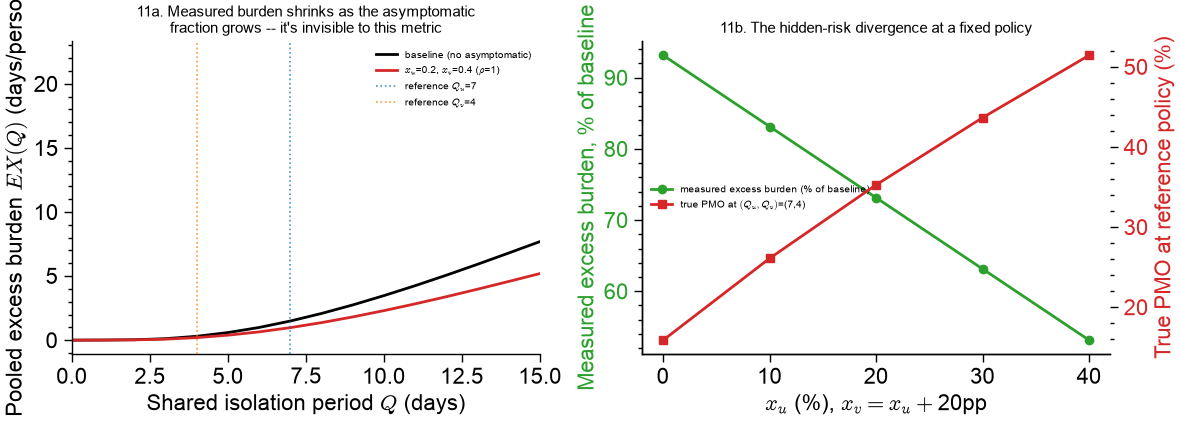


  x_u   x_v   burden %baseline   PMO at ref policy   PMO ratio
 0.00  0.20              93.1%              15.88%       2.41x
 0.10  0.30              83.1%              26.09%       3.96x
 0.20  0.40              73.1%              35.27%       5.35x
 0.30  0.50              63.1%              43.65%       6.63x
 0.40  0.60              53.1%              51.43%       7.81x

At illustrative (x_u=0.2, x_v=0.4):


  Measured excess burden: baseline=0.6156  asymptomatic-adjusted=0.4502  (drops 26.9%)
  True PMO: baseline=6.59%  asymptomatic-adjusted=35.27%  (5.35x)

Ambient p_out (Q_u=Q_v=0): baseline=0.8425  asymptomatic-adjusted (rho=1)=0.8425


In [19]:
X_U_L, X_V_L = X_U_ILLUS, X_V_ILLUS   # reuse Plot 10's illustrative split (rho=1: worst case)

# Generalized excess burden: only the (1-x)*phi isolating fraction can ever waste days (phi=1)
EX_u_asymp = (1 - X_U_L) * EX_u
EX_v_asymp = (1 - X_V_L) * EX_v
EX_pooled_baseline = THETA_VAX_COHORT * EX_v + (1 - THETA_VAX_COHORT) * EX_u
EX_pooled_asymp = THETA_VAX_COHORT * EX_v_asymp + (1 - THETA_VAX_COHORT) * EX_u_asymp

PMO_grid_baseline_asymp = pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, 0.0, 0.0, rho=1.0)
print("PMO_grid_baseline_asymp matches PMO_grid (Plot 2), max abs diff:",
      np.max(np.abs(PMO_grid_baseline_asymp - PMO_grid)))

QU_REF, QV_REF, _ = combined_min_days(PMO_grid, 0.10, Q_RANGE_FIX)
print(f"Reference policy (Plot 5's average-constrained PMO<10% optimum): Qu={QU_REF}, Qv={QV_REF}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.plot(Q_RANGE_FIX, EX_pooled_baseline, color="black", lw=2, label="baseline (no asymptomatic)")
ax.plot(Q_RANGE_FIX, EX_pooled_asymp, color="tab:red", lw=2,
        label=rf"$x_u$={X_U_L}, $x_v$={X_V_L} ($\rho$=1)")
ax.axvline(QU_REF, color="tab:blue", ls=":", lw=1.2, alpha=0.8, label=rf"reference $Q_u$={QU_REF}")
ax.axvline(QV_REF, color="tab:orange", ls=":", lw=1.2, alpha=0.8, label=rf"reference $Q_v$={QV_REF}")
ax.set_xlabel("Shared isolation period $Q$ (days)")
ax.set_ylabel("Pooled excess burden $EX(Q)$ (days/person)")
ax.set_xlim(0, 15)
ax.set_title("11a. Measured burden shrinks as the asymptomatic\nfraction grows -- it's invisible to this metric", fontsize=10.5)
ax.legend(frameon=False, fontsize=7.5)
ax.tick_params(top=False, right=False)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

ax = axes[1]
X_U_SWEEP2 = np.array([0.0, 0.1, 0.2, 0.3, 0.4])
GAP2 = 0.20
ex_baseline_ref = THETA_VAX_COHORT * EX_v[QV_REF] + (1 - THETA_VAX_COHORT) * EX_u[QU_REF]
pmo_baseline_ref = PMO_grid_baseline_asymp[QU_REF, QV_REF]
burden_ratios, pmo_pcts = [], []
for xu in X_U_SWEEP2:
    xv = xu + GAP2
    ex_ref = (THETA_VAX_COHORT * (1 - xv) * EX_v[QV_REF]
              + (1 - THETA_VAX_COHORT) * (1 - xu) * EX_u[QU_REF])
    burden_ratios.append(ex_ref / ex_baseline_ref)
    pmo_here = pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, xv, xu, rho=1.0)[QU_REF, QV_REF]
    pmo_pcts.append(100 * pmo_here)
burden_ratios = np.array(burden_ratios)
pmo_pcts = np.array(pmo_pcts)

l1, = ax.plot(100 * X_U_SWEEP2, 100 * burden_ratios, color="tab:green", lw=2, marker="o",
              label="measured excess burden (% of baseline)")
ax.set_xlabel(r"$x_u$ (%), $x_v=x_u+$" + f"{int(100 * GAP2)}pp")
ax.set_ylabel("Measured excess burden, % of baseline", color="tab:green")
ax.tick_params(axis="y", labelcolor="tab:green")
ax2 = ax.twinx()
l2, = ax2.plot(100 * X_U_SWEEP2, pmo_pcts, color="tab:red", lw=2, marker="s",
               label=rf"true PMO at $(Q_u,Q_v)$=({QU_REF},{QV_REF})")
ax2.set_ylabel("True PMO at reference policy (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax.set_title("11b. The hidden-risk divergence at a fixed policy", fontsize=10.5)
ax.legend(handles=[l1, l2], frameon=False, fontsize=7.5, loc="center left")
ax.tick_params(top=False, right=False)
ax.spines["top"].set_visible(False)

# fig.suptitle("Plot 11: post-release / excess-burden interaction -- illustrative sensitivity, not a sourced empirical estimate", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"\n{'x_u':>5} {'x_v':>5}  {'burden %baseline':>17}  {'PMO at ref policy':>18}  {'PMO ratio':>10}")
for xu, br, pmo in zip(X_U_SWEEP2, burden_ratios, pmo_pcts):
    print(f"{xu:5.2f} {xu + GAP2:5.2f}  {100 * br:16.1f}%  {pmo:17.2f}%  {pmo / (100 * pmo_baseline_ref):9.2f}x")

print(f"\nAt illustrative (x_u={X_U_L}, x_v={X_V_L}):")
ex_ref_illus = (THETA_VAX_COHORT * (1 - X_V_L) * EX_v[QV_REF]
                + (1 - THETA_VAX_COHORT) * (1 - X_U_L) * EX_u[QU_REF])
pmo_ref_illus = pdf_pmo_2d_sampled_asymp(R_v_i, R_u_i, THETA_VAX_COHORT, X_V_L, X_U_L, rho=1.0)[QU_REF, QV_REF]
print(f"  Measured excess burden: baseline={ex_baseline_ref:.4f}  asymptomatic-adjusted={ex_ref_illus:.4f}  "
      f"(drops {100 * (1 - ex_ref_illus / ex_baseline_ref):.1f}%)")
print(f"  True PMO: baseline={100 * pmo_baseline_ref:.2f}%  asymptomatic-adjusted={100 * pmo_ref_illus:.2f}%  "
      f"({pmo_ref_illus / pmo_baseline_ref:.2f}x)")

# Ambient p_out invariance check (rho=1 algebraic identity -- see markdown below)
p_out_ambient_asymp = pdf_pmo_1d_sampled_asymp(R_v_i[:, :1], R_u_i[:, :1], THETA_VAX_COHORT, X_V_L, X_U_L, rho=1.0)[0]
print(f"\nAmbient p_out (Q_u=Q_v=0): baseline={P_OUT_AMBIENT:.4f}  "
      f"asymptomatic-adjusted (rho=1)={p_out_ambient_asymp:.4f}")

**Note.** At the reference policy ($Q_u=7,Q_v=4$, Plot 5's average-constrained PMO$<10\%$
optimum), the divergence is stark. Measured excess burden drops from $0.6156$ to $0.4502$
days/person ($-26.9\%$, looking like the policy got cheaper), while the true outbreak
probability rises from $6.59\%$ to $35.27\%$ ($5.35\times$, the policy failing far more often
than the burden metric would suggest). Panel 12b's sweep shows this isn't a one-off: as $x_u$
rises from $0\%$ to $40\%$ ($x_v=x_u+20$pp fixed), measured burden falls monotonically from
$93.1\%$ to $53.1\%$ of baseline while true PMO climbs from $2.41\times$ to $7.81\times$
baseline. The two lines move in opposite directions across the entire sweep. That's the exact
"hidden risk" signature: the metric a policymaker can actually observe (recorded
isolation-days) improves precisely as the metric they actually care about (outbreak risk)
deteriorates.

**Ambient risk is unchanged at $\rho=1$** ($p_{\text{out}}^{\text{ambient}}=84.25\%$ either
way). This isn't a coincidence, it's an exact algebraic identity at this one evaluation point.
$Q_u=Q_v=0$ means the "isolating" and "full/never-isolates" $R$ values are identical by
construction, since nobody has isolated yet, so at $\rho=1$ every type transmits the same
amount regardless of $x$, and the mixture collapses back to the $x$-free baseline exactly.
This identity breaks as soon as $\rho\neq1$ or $Q>0$. It's specific to the ambient reference
point, not a general finding that asymptomatic fraction is irrelevant to outbreak risk (Plot
10 and the rest of this plot show precisely the opposite once isolation actually starts).


## Summary

Every quantity in this notebook comes from the same 1000 simulated patients (the real
Singapore age pyramid plus Ejima's NLME draws), never from a 2-point median approximation.
That covers calibration, transmission potential, PMO, expected post-release counts,
compliance and acquisition sensitivity, and excess burden.

**Design choices:**
- $\kappa$ is fixed throughout and never rescaled, and every fixed point is built directly on
  the population-sampled patients rather than a representative-trajectory approximation. This
  is what lets population heterogeneity propagate consistently into every downstream metric
  (PMO, excess burden, post-release risk) without needing an after-the-fact correction.
- A handful of simplifying assumptions are locked in this notebook, each with its own
  parameter already sitting in the model, so relaxing any of them later is a matter of
  sweeping that parameter rather than rebuilding anything:
  - $\eta=1$: vaccinated recipients are assumed just as susceptible to acquiring infection as
    unvaccinated recipients. Plot 9 relaxes this as an illustrative sweep.
  - $\varphi=1$: everyone who tests positive is assumed to comply fully with isolation.
    Plot 7 and Plot 7b relax this.
  - $\rho=1$ and $x_v=x_u=0$: asymptomatic infection is switched off everywhere except
    Plot 10 and Plot 11, where they're swept as an illustrative extension.
  - $\varepsilon=0$ and $\tau_{\text{det}}=0$: isolation is assumed perfectly leak-proof, and
    detection is assumed to coincide with symptom onset. Neither is relaxed anywhere in this
    notebook.
  - Every newly acquired infection is drawn from the population mixture $\theta$ regardless
    of the infector's own vaccination status, so a vaccinated source is no more or less
    likely than an unvaccinated one to infect another vaccinated person. There's no
    assortative-mixing parameter in the model to relax this.
  - Every simulated patient carries the same weight in `mean_i(...)`, so the model has no
    contact-rate or activity heterogeneity beyond what viral kinetics already gives it.
    Adding a per-patient multiplier, drawn from something like a Gamma distribution with
    dispersion $k$, would let the model represent superspreading on top of the biological
    heterogeneity already here.

Plots 10-11 extend the population-sampled fixed point to asymptomatic infection ($\S9$ of the
PDF's own extensions list): a $\rho$ (relative infectiousness) and vaccination-stratified
fraction ($x_v,x_u$) sweep, and the resulting divergence between measured excess isolation
burden and true outbreak probability. Measured burden shrinks as the never-tested
asymptomatic fraction grows, since it was never isolated to begin with, while true outbreak
probability rises sharply. Like $\varphi$ and $\eta$, $x_v,x_u,\rho$ are illustrative-only.
Ejima et al.'s NLME fit is to symptomatic cases by construction, so no arm of this project's
data can estimate them directly.
